# Reconstructing atrial conduction barriers from sparse observations using an anisotropic phase-field model

In [1]:
from pathlib import Path
from contextlib import redirect_stdout
import os, sys, json

REPO = next((path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
             if (path / "code/input_loader.py").is_file()), None)
if REPO is None:
    raise FileNotFoundError("Open this notebook inside the repository.")
sys.path.insert(0, str(REPO / "code"))
from reproduce import prepare_repository, run_research
ROOT = prepare_repository(REPO)

import numpy as np
import pandas as pd
from IPython.display import display, HTML, Image, Video
from notebook_tables import generate_tables

WORKERS = 6
RECOMPUTE = False
TABLE_SOURCE = "manuscript.tex"


$$
\partial_\tau u=\mathcal L_K\!\left[u^3-u-\mu\mathcal L_Ku-\nu a_N(\mathcal L_Ku)|K^{1/2}\nabla_g u|\right]+f-\lambda u,
\qquad a_N(z)=\frac{2}{\pi}\arctan(Nz).
$$

## Computation

In [2]:
with (ROOT / "notebook_execution.log").open("a") as log, redirect_stdout(log):
    WORK, execution = run_research(ROOT, workers=WORKERS, fresh=RECOMPUTE)
display(pd.DataFrame([
    {"Study": name.replace("_", " "), "Seconds": round(item["elapsed_seconds"], 1), "Status": item["status"]}
    for name, item in execution["stages"].items()
]).set_index("Study"))

,Seconds,Status
Study,,
core,1044.8,completed
algebraic surface verification,7.9,completed
applied,935.5,completed
support exclusion,675.7,completed
boundary coverage,1105.8,completed
patient base,337.0,completed
factor reuse benchmark,126.2,completed
patient extension,1885.1,completed
synthetic summary,12.6,completed


In [3]:
tables = {item["label"]: item for item in generate_tables(ROOT / TABLE_SOURCE)}

def table(label):
    display(HTML(tables[label]["html"]))

def figure(name):
    display(Image(filename=str(WORK / "figures" / (name + ".png")), width=1100))

def results(name, columns=None):
    frame = pd.read_csv(WORK / "data" / name)
    display(frame if columns is None else frame[columns])

## Numerical configuration

In [4]:
table("tab:configuration")

Experiment,Reconstruction grid/time,Phase parameters,EP configuration
1. Exact verification,"temporal: \(95^2\), \(\Delta\tau=2\times10^{-4}\) to \(2.5\times10^{-5}\); spatial: \(15^2,23^2,31^2,39^2\), \(\Delta\tau=2.5\times10^{-7}\); \(T=10^{-3}\); \(K=\operatorname{diag}(1,0.6)\)","\(\mu=3\times10^{-3}\), \(\nu=5\times10^{-2}\), classifier scale \(10^{-2}\)",\(96^2\) periodic; \(T_{\rm EP}=0.04\); \(\Delta t=2\times10^{-3}\) to \(2.5\times10^{-4}\)
2. Graph limit,"\(31^2,47^2,63^2\); \(T=5\times10^{-4}\); \(K=\operatorname{diag}(1,0.6)\); coupled halving of \(\Delta\tau\)","\(\mu=3\times10^{-3}\), \(\nu=10^{-2}\); \(N=8,32,128,512\)",not used
3. Conduction-scale characterisation,not used,not used,"spatial: \(\Delta x=1,0.5,0.25,0.125\) at \(\Delta t=0.01\); temporal: \(\Delta t=0.04,0.02,0.01\) at \(\Delta x=0.5\); 350 ms"
4. Sparse reconstruction,"\(81^2\) on \(60\times60\); \(K=\operatorname{diag}(1,0.6)\); \(\Delta\tau=0.01\); common \(T=1.20\); terminal window \(\delta=0.12\)","\(\mu=0.30\); \(\nu=0\) or \(0.20\); 5 fixed geometries, each with 4 spatial-blackout rotations",not used
5. PVI conductance and EP,prescribed diffusivity on \(121^2\); 3-by-3 subcell averages,"widths \(3,4.5,6,9\); six residual-diffusivity levels; angles \(0^\circ,45^\circ,90^\circ\)","\(\Delta x=0.496\), \(\Delta t=0.02\); 210 ms; no-flux; entrance and exit pacing"
6. Patient surfaces,"6 prior-PVI LA meshes; scalar P1 elements; \(\Delta\tau=0.01\), \(T=1.20\); 12-state average",\(\mu=0.30\); \(\nu=0\) or \(0.20\); isotropic surface tensor; left/right PV blackouts,exploratory P3 surface EP in Appendix B
7. Forward transfer,"full reference and reconstructed scores from Experiment 4; \(81^2\) chart, with refinement controls",same score-to-diffusivity map for all fields; both acquisition rules,"\(121^2\) and \(161^2\); \(\Delta t=0.02,0.01\); 210 ms; both pacing directions"


## Convex predictor

In [5]:
table("tab:graph-certificate")
results("graph_error_certificate.csv", ["backend", "admm_tolerance", "rms_error_bound", "rms_difference_from_tight_solve"])

Predictor,Tolerance,RMS bound,RMS difference
"Fourier, \(33^2\)",\(10^{-4}\),\(2.685\times10^{-5}\),\(8.588\times10^{-6}\)
,\(10^{-6}\),\(2.343\times10^{-7}\),\(5.883\times10^{-8}\)
,\(10^{-8}\),\(3.182\times10^{-9}\),\(4.945\times10^{-10}\)
"Sphere, 162 vertices",\(10^{-4}\),\(1.660\times10^{-5}\),\(1.135\times10^{-5}\)
,\(10^{-6}\),\(1.604\times10^{-7}\),\(1.034\times10^{-7}\)
,\(10^{-8}\),\(1.377\times10^{-9}\),\(8.706\times10^{-10}\)


,backend,admm_tolerance,rms_error_bound,rms_difference_from_tight_solve
0,Fourier_33x33,1.000000e-04,2.684511e-05,8.588059e-06
1,Fourier_33x33,1.000000e-06,2.342912e-07,5.882582e-08
2,Fourier_33x33,1.000000e-08,3.182090e-09,4.944938e-10
3,P1_sphere_162,1.000000e-04,1.660341e-05,1.134610e-05
4,P1_sphere_162,1.000000e-06,1.604432e-07,1.034141e-07
5,P1_sphere_162,1.000000e-08,1.376613e-09,8.706228e-10


## Exact-solution verification

\(n\),\(h\),\(E_0\),\(E_{\mathcal L_{K}}\),"\(E_{H^2,\tau}\)"
15,0.06667,\(1.3322\times10^{-2}\),\(8.9036\times10^{-2}\),\(6.3808\times10^{-2}\)
23,0.04348,\(3.6927\times10^{-3}\) (3.002),\(2.7102\times10^{-2}\) (2.783),\(2.1432\times10^{-2}\) (2.552)
31,0.03226,\(6.8053\times10^{-4}\) (5.666),\(5.5015\times10^{-3}\) (5.342),\(4.6914\times10^{-3}\) (5.089)
39,0.02564,\(1.0964\times10^{-4}\) (7.952),\(1.0368\times10^{-3}\) (7.269),\(9.4435\times10^{-4}\) (6.982)


Solver,time step,\(E_0\) or \(E_V^{L^2}\),\(E_{\mathcal L_{K}}\) or \(E_V^{H^1}\),"\(E_{H^2,\tau}\) or \(E_r^{L^2}\)",maximum CFL
Phase,\(2.0\times10^{-4}\),\(1.110\times10^{-3}\),\(4.091\times10^{-3}\),\(2.870\times10^{-3}\),–
,\(1.0\times10^{-4}\),\(6.00\times10^{-4}\) (0.888),\(2.311\times10^{-3}\) (0.824),\(1.554\times10^{-3}\) (0.884),–
,\(5.0\times10^{-5}\),\(3.13\times10^{-4}\) (0.937),\(1.237\times10^{-3}\) (0.902),\(8.17\times10^{-4}\) (0.928),–
,\(2.5\times10^{-5}\),\(1.60\times10^{-4}\) (0.967),\(6.41\times10^{-4}\) (0.948),\(4.20\times10^{-4}\) (0.959),–
EP,\(2.0\times10^{-3}\),\(1.10\times10^{-5}\),\(8.50\times10^{-5}\),\(6.10\times10^{-5}\),0.0295
,\(1.0\times10^{-3}\),\(5.48\times10^{-6}\) (1.004),\(4.23\times10^{-5}\) (1.004),\(3.05\times10^{-5}\) (1.000),0.0147
,\(5.0\times10^{-4}\),\(2.72\times10^{-6}\) (1.008),\(2.10\times10^{-5}\) (1.008),\(1.52\times10^{-5}\) (1.000),0.00737
,\(2.5\times10^{-4}\),\(1.35\times10^{-6}\) (1.017),\(1.04\times10^{-5}\) (1.017),\(7.62\times10^{-6}\) (1.000),0.00369


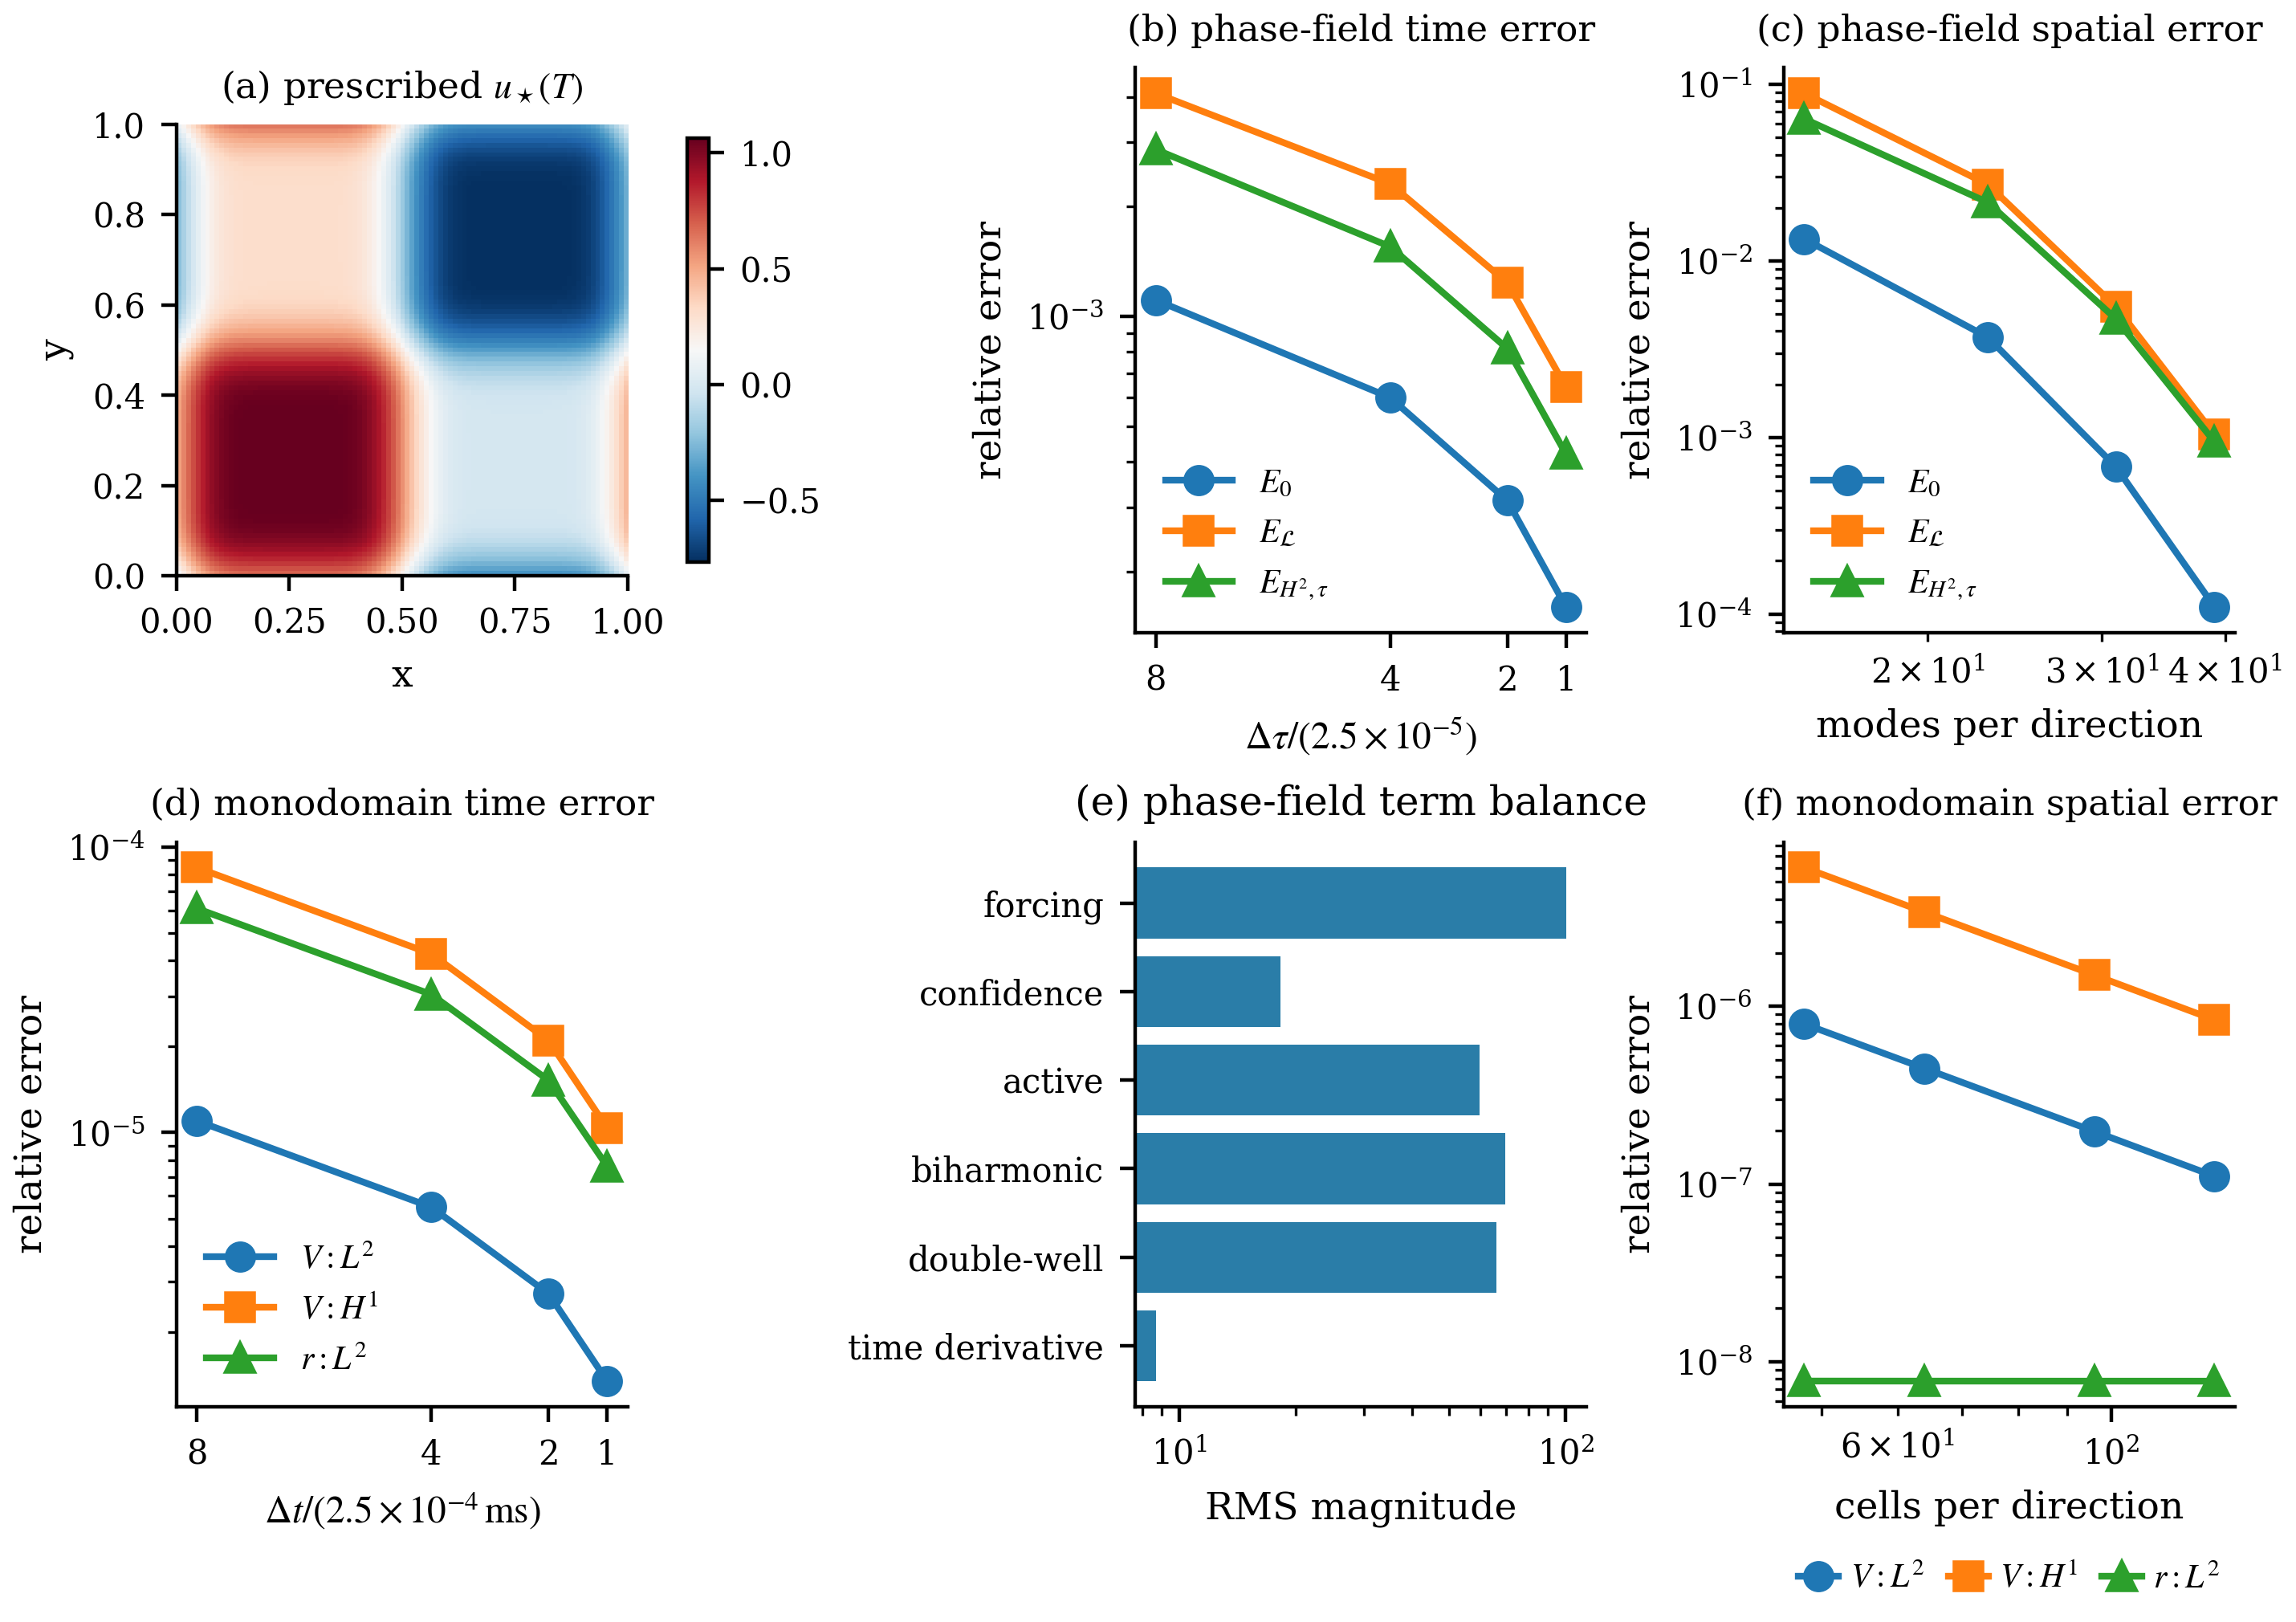

In [6]:
table("tab:phase-spatial")
table("tab:exact")
figure("fig1_exact_verification")

## Sign-graph limit

\(N\),\(E_N^{H^{2}}\),\(\max_\tau E_N^{L^{2}}\),\(E_N^{\chi}\)
8,\(2.2675\times10^{-2}\),\(7.75\times10^{-4}\),\(5.8544\times10^{-2}\)
32,\(8.943\times10^{-3}\),\(2.65\times10^{-4}\),\(1.9011\times10^{-2}\)
128,\(3.314\times10^{-3}\),\(8.5\times10^{-5}\),\(5.852\times10^{-3}\)
512,\(1.189\times10^{-3}\),\(2.6\times10^{-5}\),\(1.767\times10^{-3}\)


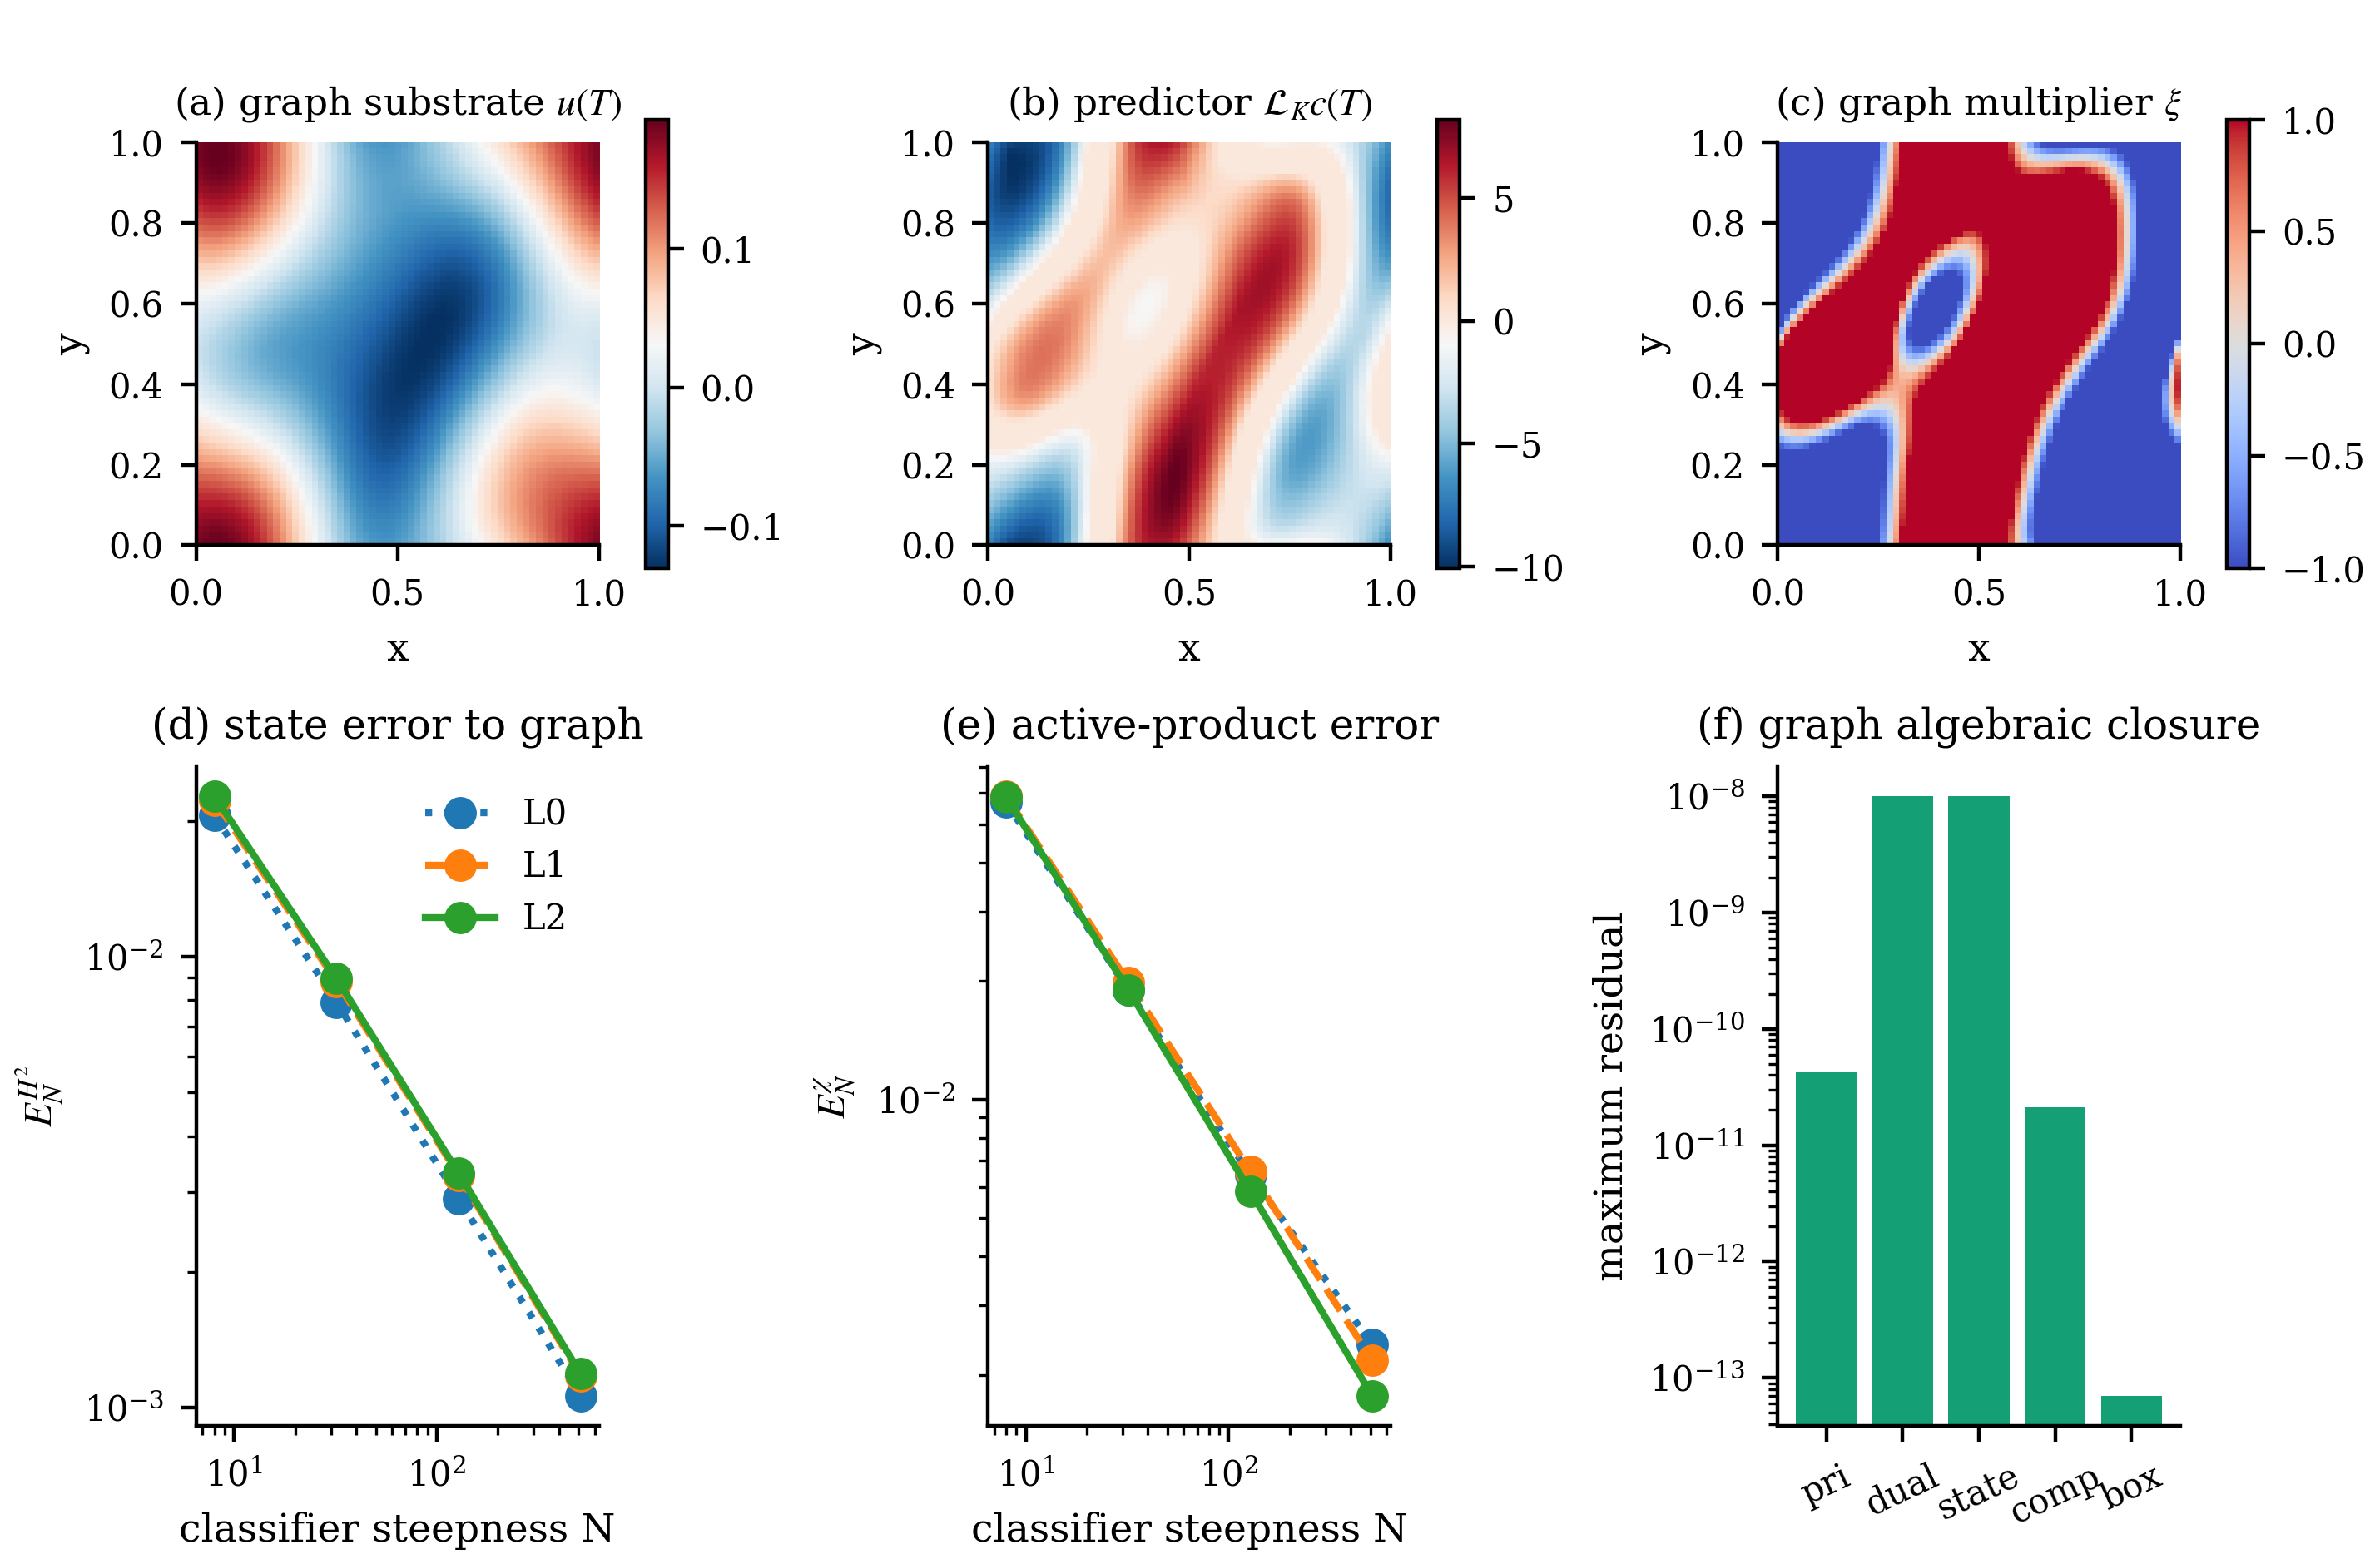

In [7]:
table("tab:graph-limit")
figure("fig2_graph_limit")

## Reconstruction and observation coverage

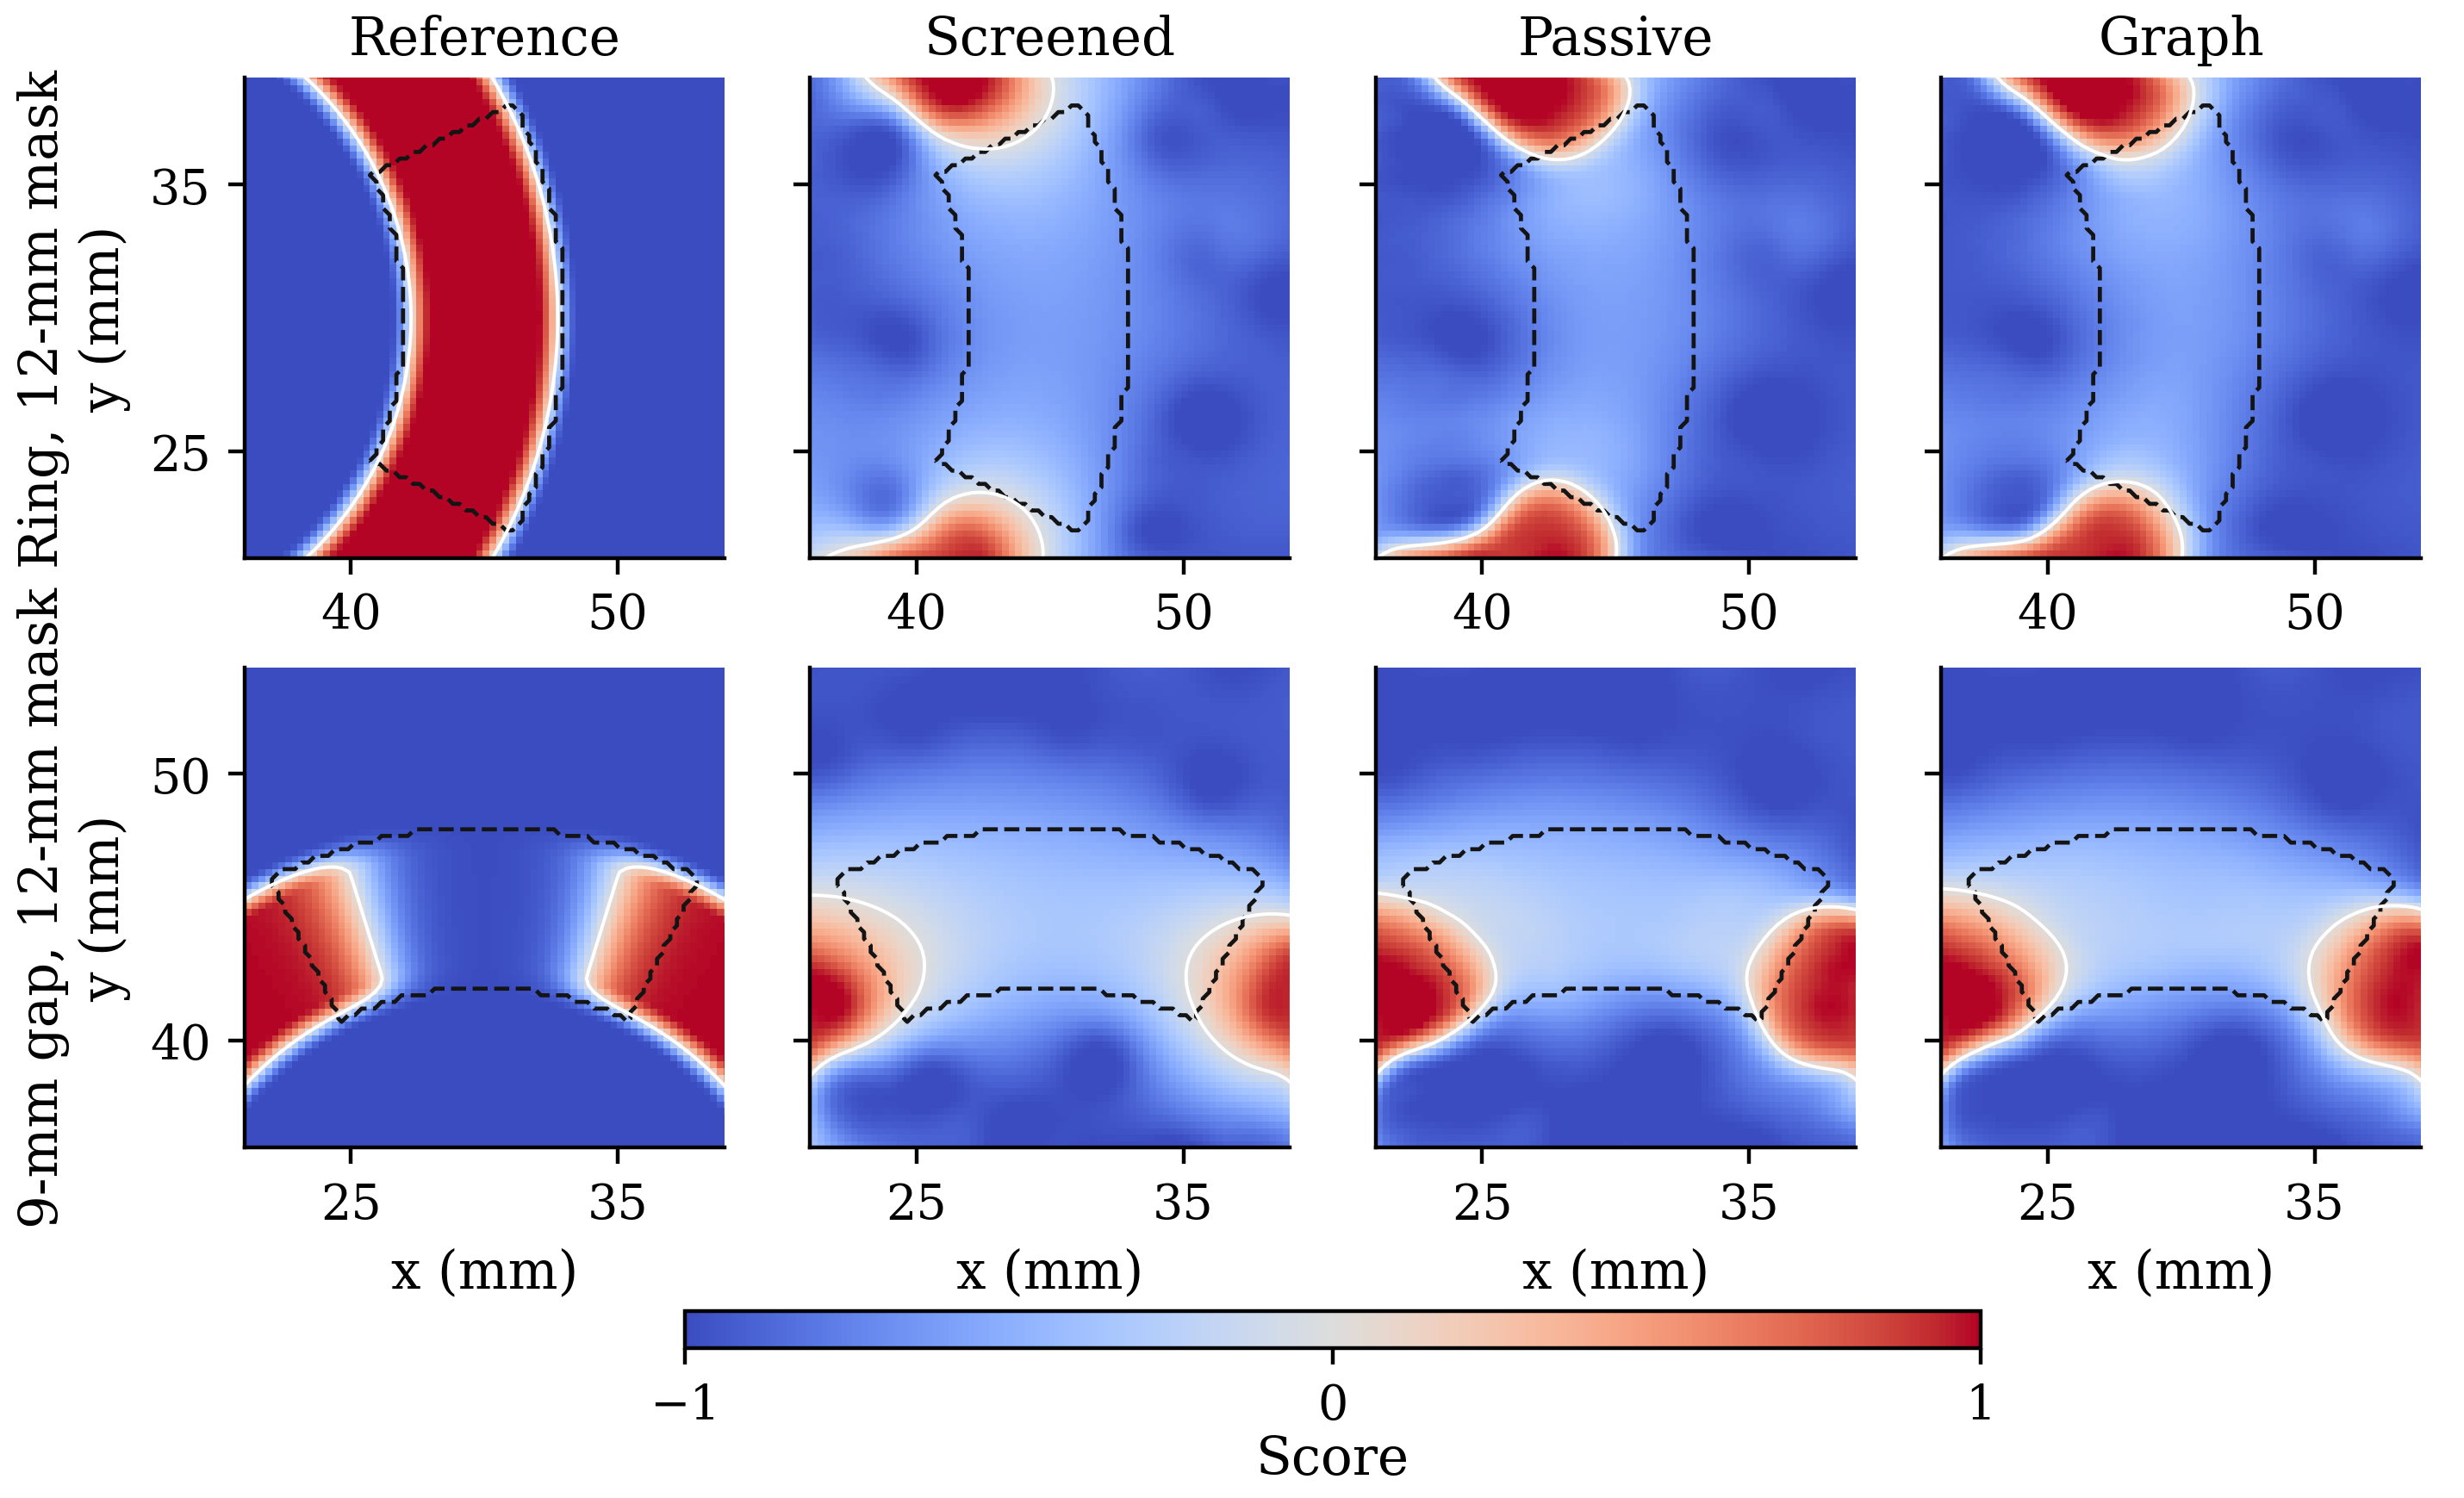

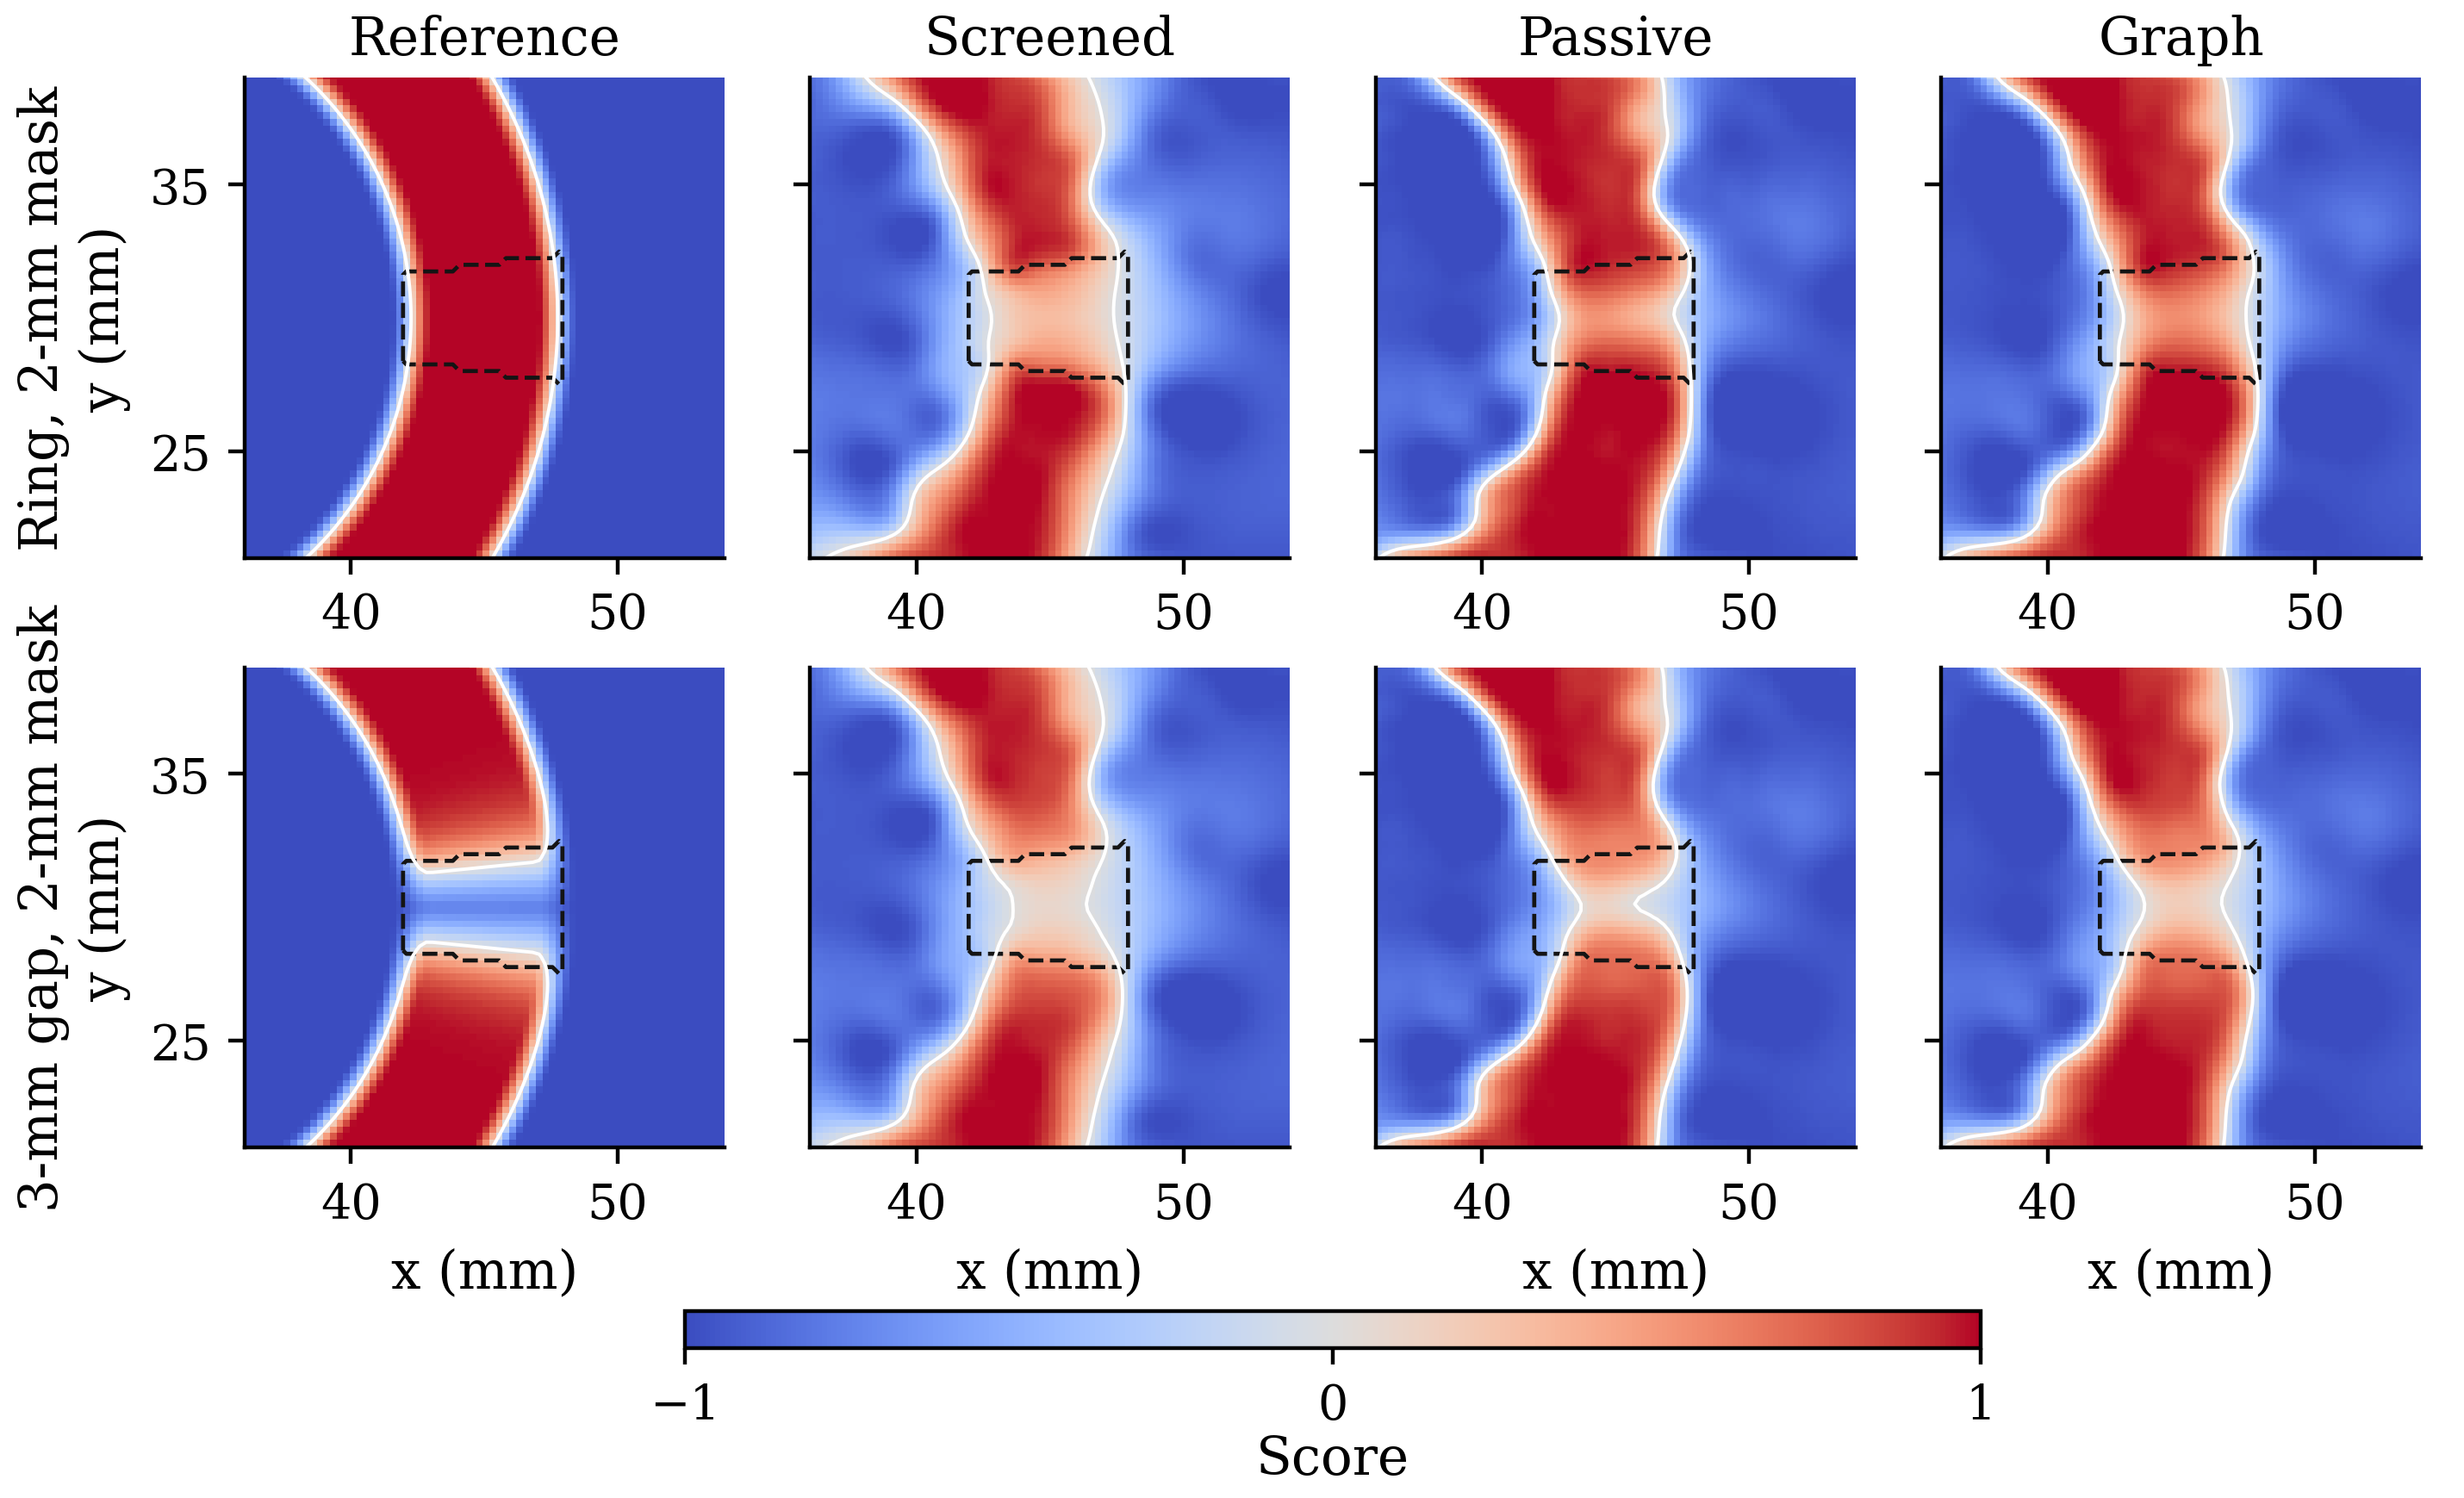

Geometry,arc,\(n=81\),\(n=121\),\(n=161\),half step
complete ring,2 mm,\(+0.00196\),\(-0.00292\),\(+0.00046\),\(+0.00141\)
complete ring,6 mm,\(-0.00814\),\(-0.00649\),\(-0.00741\),\(-0.00888\)
narrow gap,2 mm,\(+0.00238\),\(+0.00265\),\(+0.00234\),\(+0.00306\)
narrow gap,6 mm,\(-0.03761\),\(-0.03733\),\(-0.03843\),\(-0.04015\)
wide gap,2 mm,\(-0.00911\),\(-0.01017\),\(-0.01002\),\(-0.00890\)
wide gap,6 mm,\(-0.00984\),\(-0.00916\),\(-0.00940\),\(-0.00987\)


Method,solver CPU (s),total CPU (s),elapsed (s),ADMM/step
screened,0.0339,0.0339,0.0339,—
passive,0.5492,0.5857,0.5858,0
graph,1.9990,2.0370,2.0434,21.6


In [8]:
table("tab:sparse-size")
figure("fig4_actual_reconstructions")
figure("fig4_boundary_reconstructions")
table("tab:sparse-refinement")
table("tab:sparse-cost")

## PVI conductance and propagation

Width (mm),"\((\eta_g,\eta_{g,\mathrm c})\)",angle,\(C_h^\ast\),exit first arrival (ms),entrance first arrival (ms)
3,"\((0.3,0.26436)\)",\(0^\circ\),0.02407,39.94,27.46
6,"\((0.03,0.02948)\)",\(0^\circ\),0.006480,78.65,65.81
9,"\((0.003,0.002995)\)",\(0^\circ\),0.002264,–,–
3,"\((0.3,0.26436)\)",\(45^\circ\),0.01252,66.65,46.61
6,"\((0.03,0.02948)\)",\(45^\circ\),0.004287,112.85,94.42
9,"\((0.003,0.002995)\)",\(45^\circ\),0.002040,–,–
3,"\((0.3,0.26436)\)",\(90^\circ\),0.005556,112.86,80.77
6,"\((0.03,0.02948)\)",\(90^\circ\),0.002574,–,–
9,"\((0.003,0.002995)\)",\(90^\circ\),0.001839,–,–


Study,\(n\),\(\Delta t\) (ms),\(\Delta C_h^\ast\) (%),A exit,A entrance,B exit,B entrance
space,81,0.02,0.119,yes,no,no,no
,121,0.02,0.0975,yes,yes,no,no
,161,0.02,0.283,yes,yes,no,no (77.1%)
time,121,0.01,0.0975,yes,yes,no,no
,121,0.02,0.0975,yes,yes,no,no
,121,0.04,0.0975,yes,yes,no,no


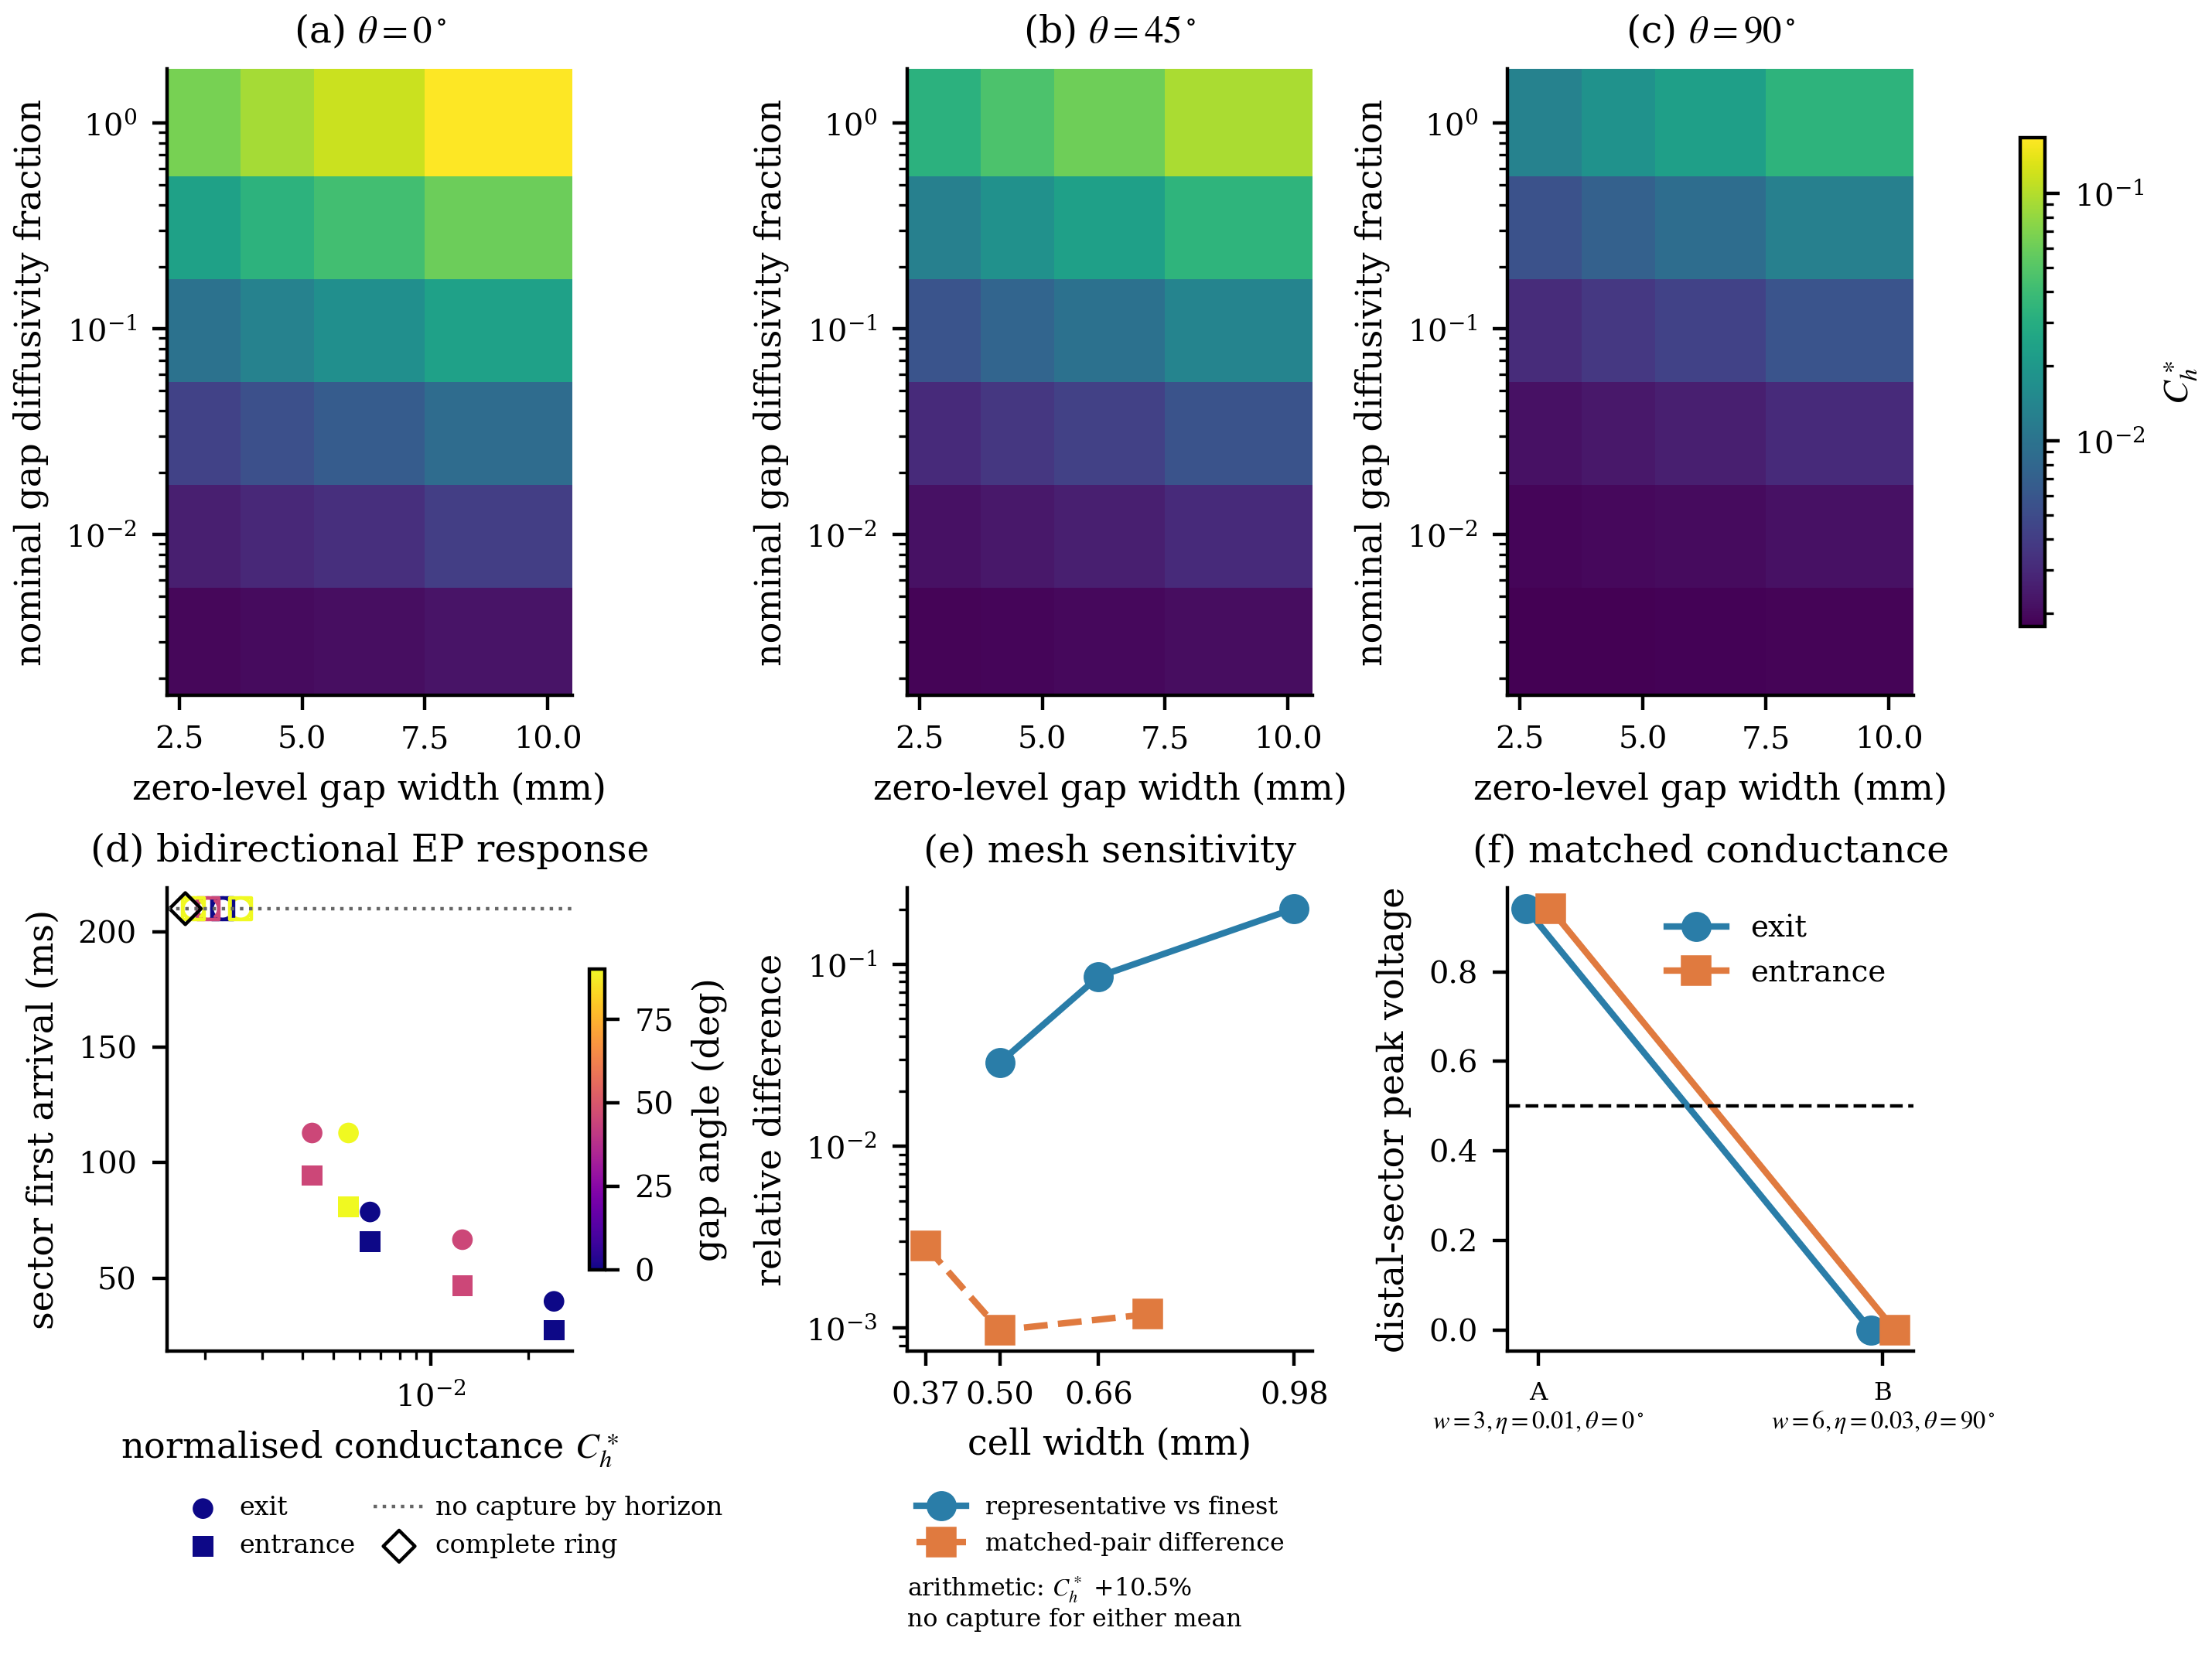

In [9]:
table("tab:phase-diagram")
table("tab:matched-refinement")
figure("fig5_pvi_capacity_phase_diagram")

## Clinical atrial surfaces

Endpoint,Screened,Passive,Graph,Difference
Score RMSE (primary),0.239082,0.238461,0.238335,\(-0.000125\)
Dice at 0.1 mV,0.584855,0.584935,0.582351,\(-0.002584\)
Absolute capacity error,0.353266,0.353012,0.353087,\(+0.000075\)


Width,Method,RMSE,Dice,Capacity error,Arc error
3 mm,Screened,0.191655,0.812670,0.169418,13.94
,Passive,0.192718,0.812286,0.162925,13.93
,Graph,0.192857,0.812781,0.162645,13.98
5 mm,Screened,0.222982,0.751918,0.208076,15.36
,Passive,0.223500,0.752137,0.203152,15.36
,Graph,0.223652,0.750805,0.202589,15.38
10 mm,Screened,0.270022,0.498275,0.353266,27.08
,Passive,0.269946,0.498275,0.353012,27.08
,Graph,0.269941,0.498042,0.353087,27.08


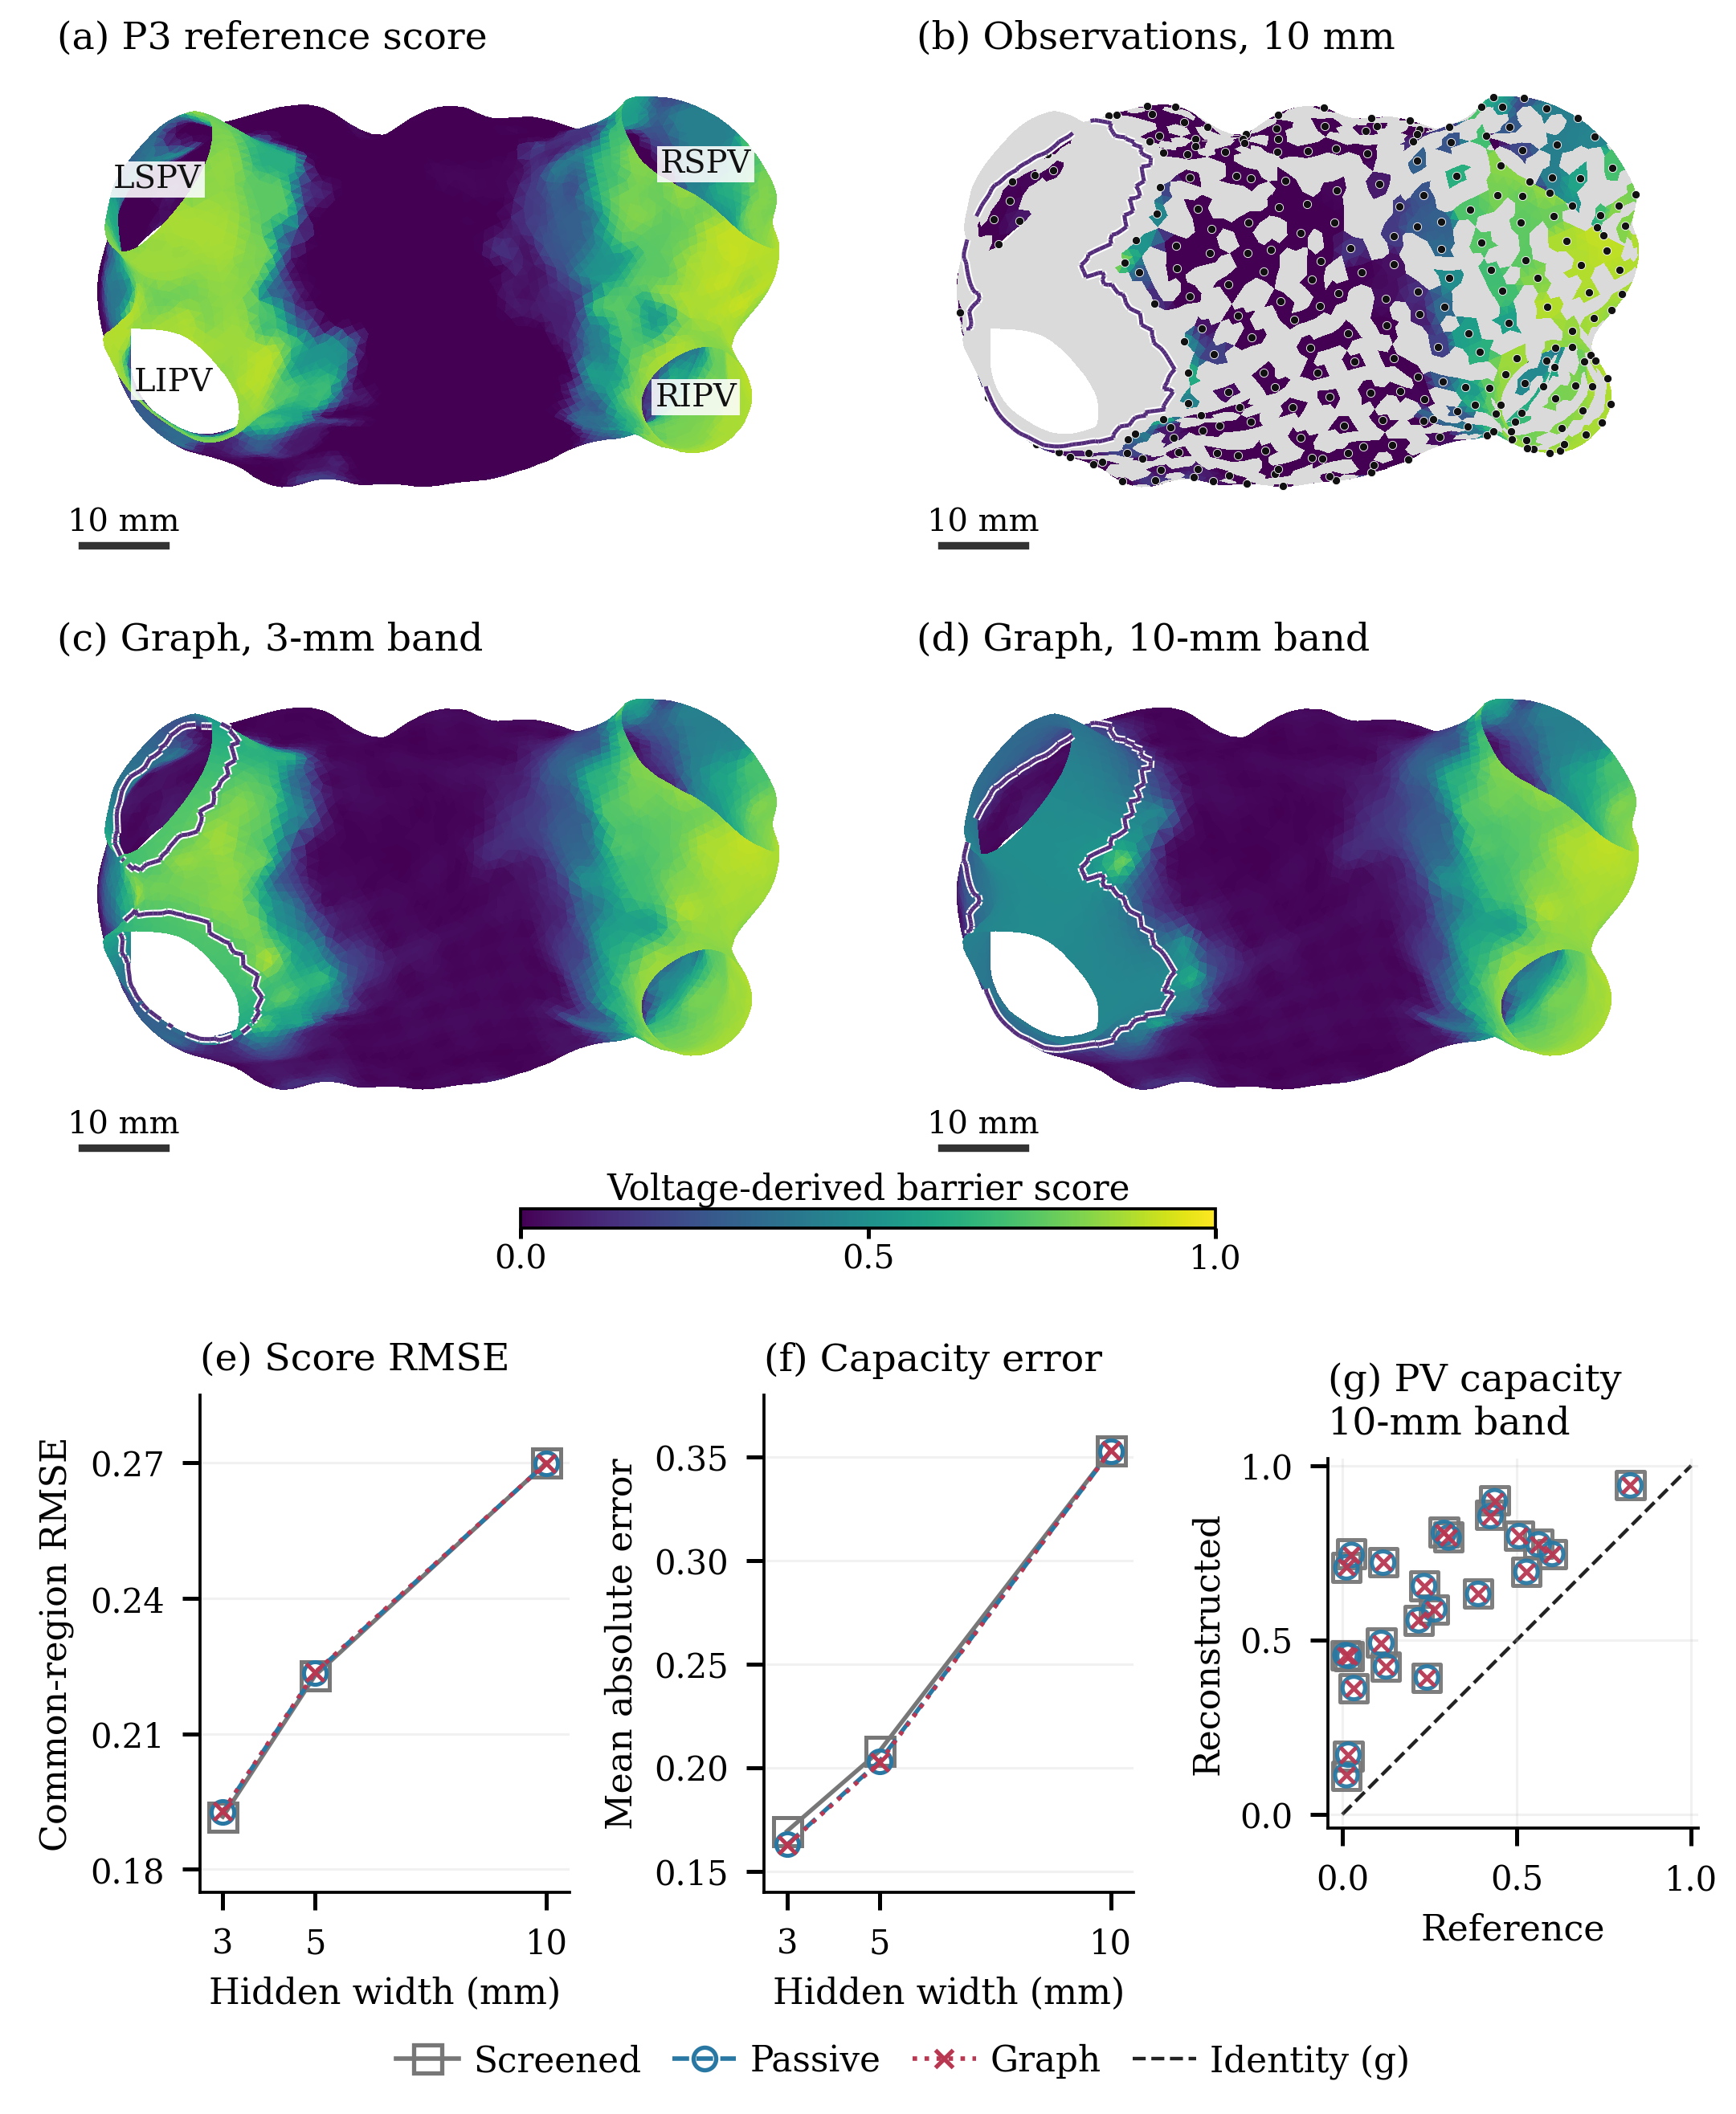

Sample,Vertices,\(\Delta\tau\),Passive RMSE,Graph RMSE,Difference(\(10^{-4}\))
Six patients,Original,0.010,0.238461,0.238335,\(-1.25047\)
,Original,0.005,0.238467,0.238341,\(-1.25883\)
"P3, left","7,482",0.010,0.302277,0.302375,\(+0.98774\)
,"7,482",0.005,0.302276,0.302382,\(+1.05361\)
,"29,326",0.010,0.302301,0.302433,\(+1.31957\)
,"29,326",0.005,0.302303,0.302442,\(+1.39531\)


In [10]:
table("tab:patient-reconstruction")
table("tab:patient-missingness")
figure("fig_patient_consolidated")
table("tab:patient-numerics")

## Reconstruction-to-propagation transfer

Field,Thresholded gaps,Normalised capacity,Exit first arrival (ms)
Reference,0,0.002093,no capture
Screened,0,0.009005,47.70
Passive,0,0.003335,77.72
Graph,0,0.003276,85.63


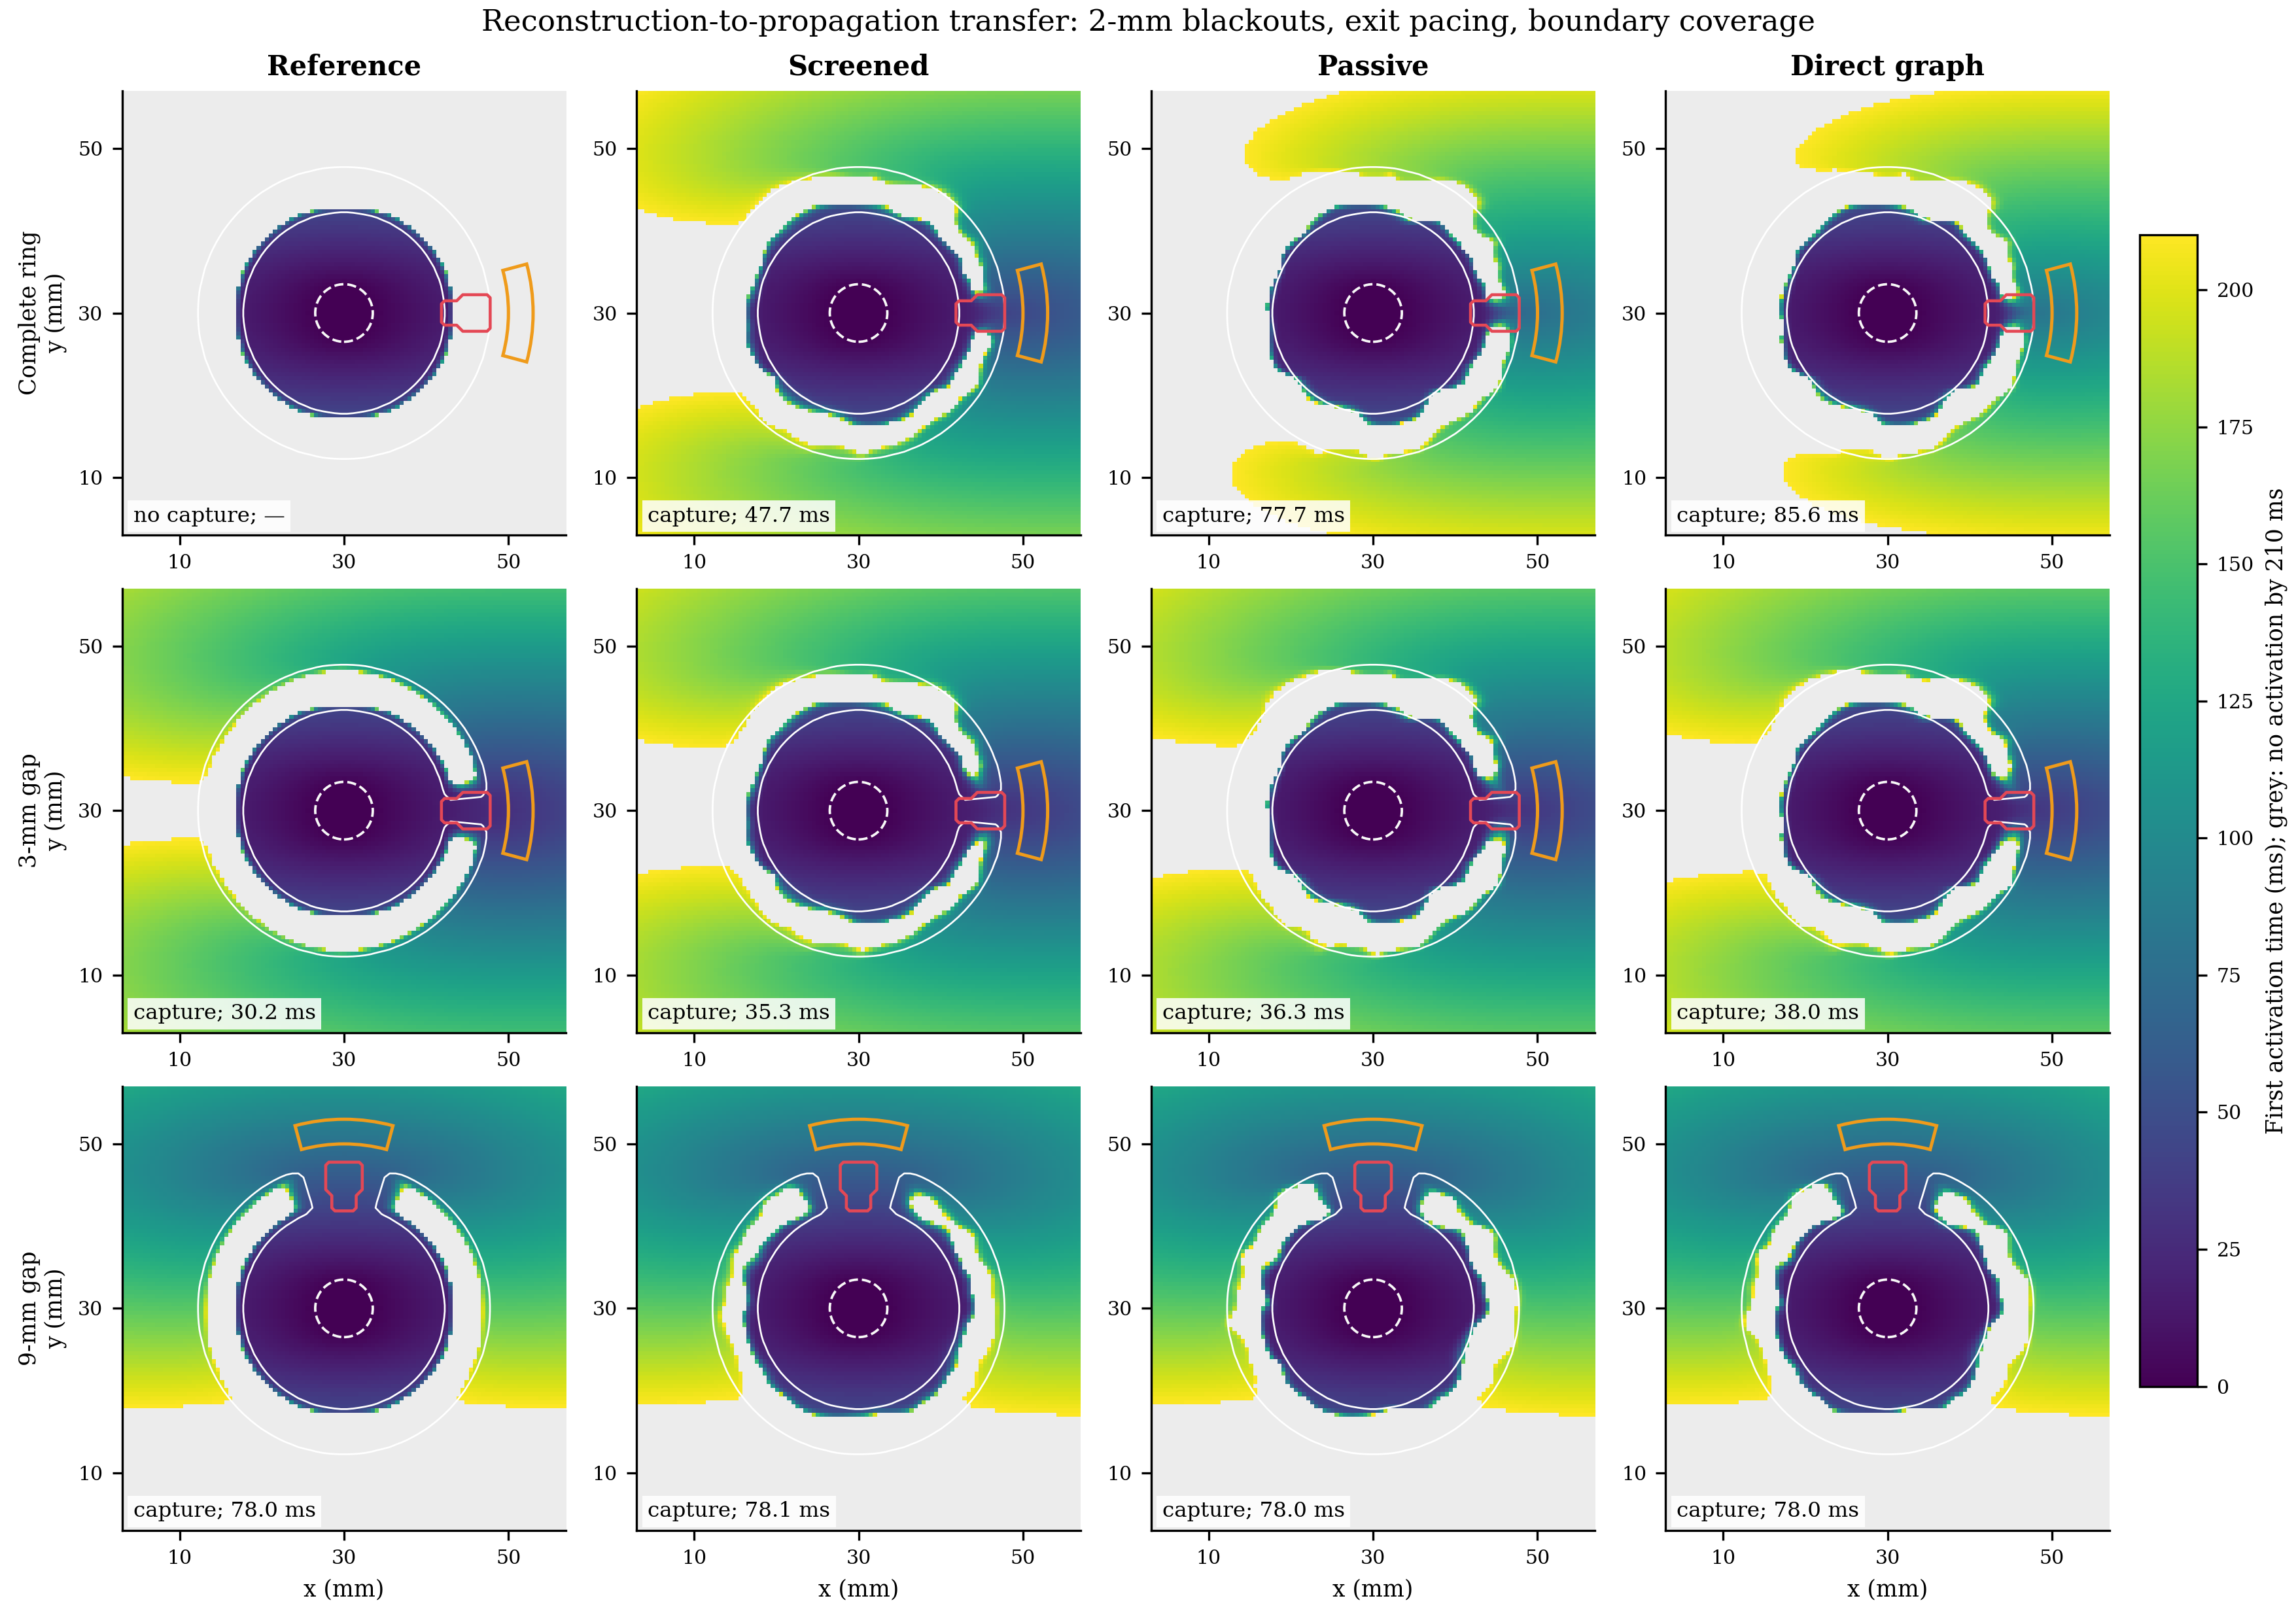

In [11]:
table("tab:reconstruction-functional")
figure("fig7_reconstruction_ep_boundary2")

## Surface verification

In [12]:
table("tab:surface-verification")
display(pd.read_csv(WORK / "patient_extension/verification/surface_annulus_refinement.csv"))
display(pd.read_csv(WORK / "patient_extension/verification/surface_sphere_graph_refinement.csv"))

Test,Error sequence,Behaviour
Planar capacity 576 triangles,capacity: \(6.46\times10^{-15}\); potential \(L^2\): \(1.94\times10^{-15}\),roundoff
"Annular capacity 256, 1024, 4096","\(5.734\times10^{-3},1.430\times10^{-3},3.573\times10^{-4}\)","orders 2.004, 2.001"
"Icosphere screened 80, 320, 1280, 5120","\(3.086\times10^{-3},9.037\times10^{-4},\) \(2.429\times10^{-4},6.256\times10^{-5}\)","orders 1.772, 1.895, 1.957"
"Icosphere graph 80, 320, 1280","nested-node RMSE \(4.140\times10^{-3},7.068\times10^{-4}\)",no rate claimed


,source,n_radial,n_angular,n_vertices,n_triangles,h_proxy,computed_capacity,exact_circular_capacity,capacity_relative_error,observed_order,order_defined,normalized_capacity,free_relative_residual,flux_energy_defect,minimum_angle_degrees,minimum_mean_ratio_quality
0,synthetic_polygonal_annulus,4,32,160,256,0.2500,15.498391,15.410024,0.005734,0.000000,0,1.7,5.066829e-16,3.438467e-16,41.267289,0.821098
1,synthetic_polygonal_annulus,8,64,576,1024,0.1250,15.432061,15.410024,0.001430,2.003640,1,1.7,7.293717e-16,2.302164e-16,41.389153,0.841579
2,synthetic_polygonal_annulus,16,128,2176,4096,0.0625,15.415530,15.410024,0.000357,2.000908,1,1.7,1.387835e-15,1.843706e-15,41.419615,0.850798


,source,refinement_level,n_vertices,n_triangles,pseudo_time_steps,nested_node_RMSE,nested_error_defined,state_min,state_max,max_admm_iterations,max_state_relative_residual,max_graph_projection_relative_residual,max_mass_source_defect
0,synthetic_unit_icosphere,1,42,80,4,0.000000,0,-0.642066,0.642066,88,9.300136e-08,1.284385e-10,2.122902e-16
1,synthetic_unit_icosphere,2,162,320,4,0.004140,1,-0.671197,0.671197,145,9.860208e-08,7.724736e-11,5.478589e-15
2,synthetic_unit_icosphere,3,642,1280,4,0.000707,1,-0.672567,0.672567,174,9.657461e-08,3.947603e-11,2.525094e-14


## Patient-surface propagation

Hidden width,Field,Distal activation (%),Arrival RMSE (ms)
\(3\) mm,Reference,67.62,0.00
,Screened,71.46,7.17
,Passive,71.19,6.75
,Graph,71.13,6.69
\(10\) mm,Reference,67.62,0.00
,Screened,76.50,22.69
,Passive,76.05,22.36
,Graph,76.11,22.36


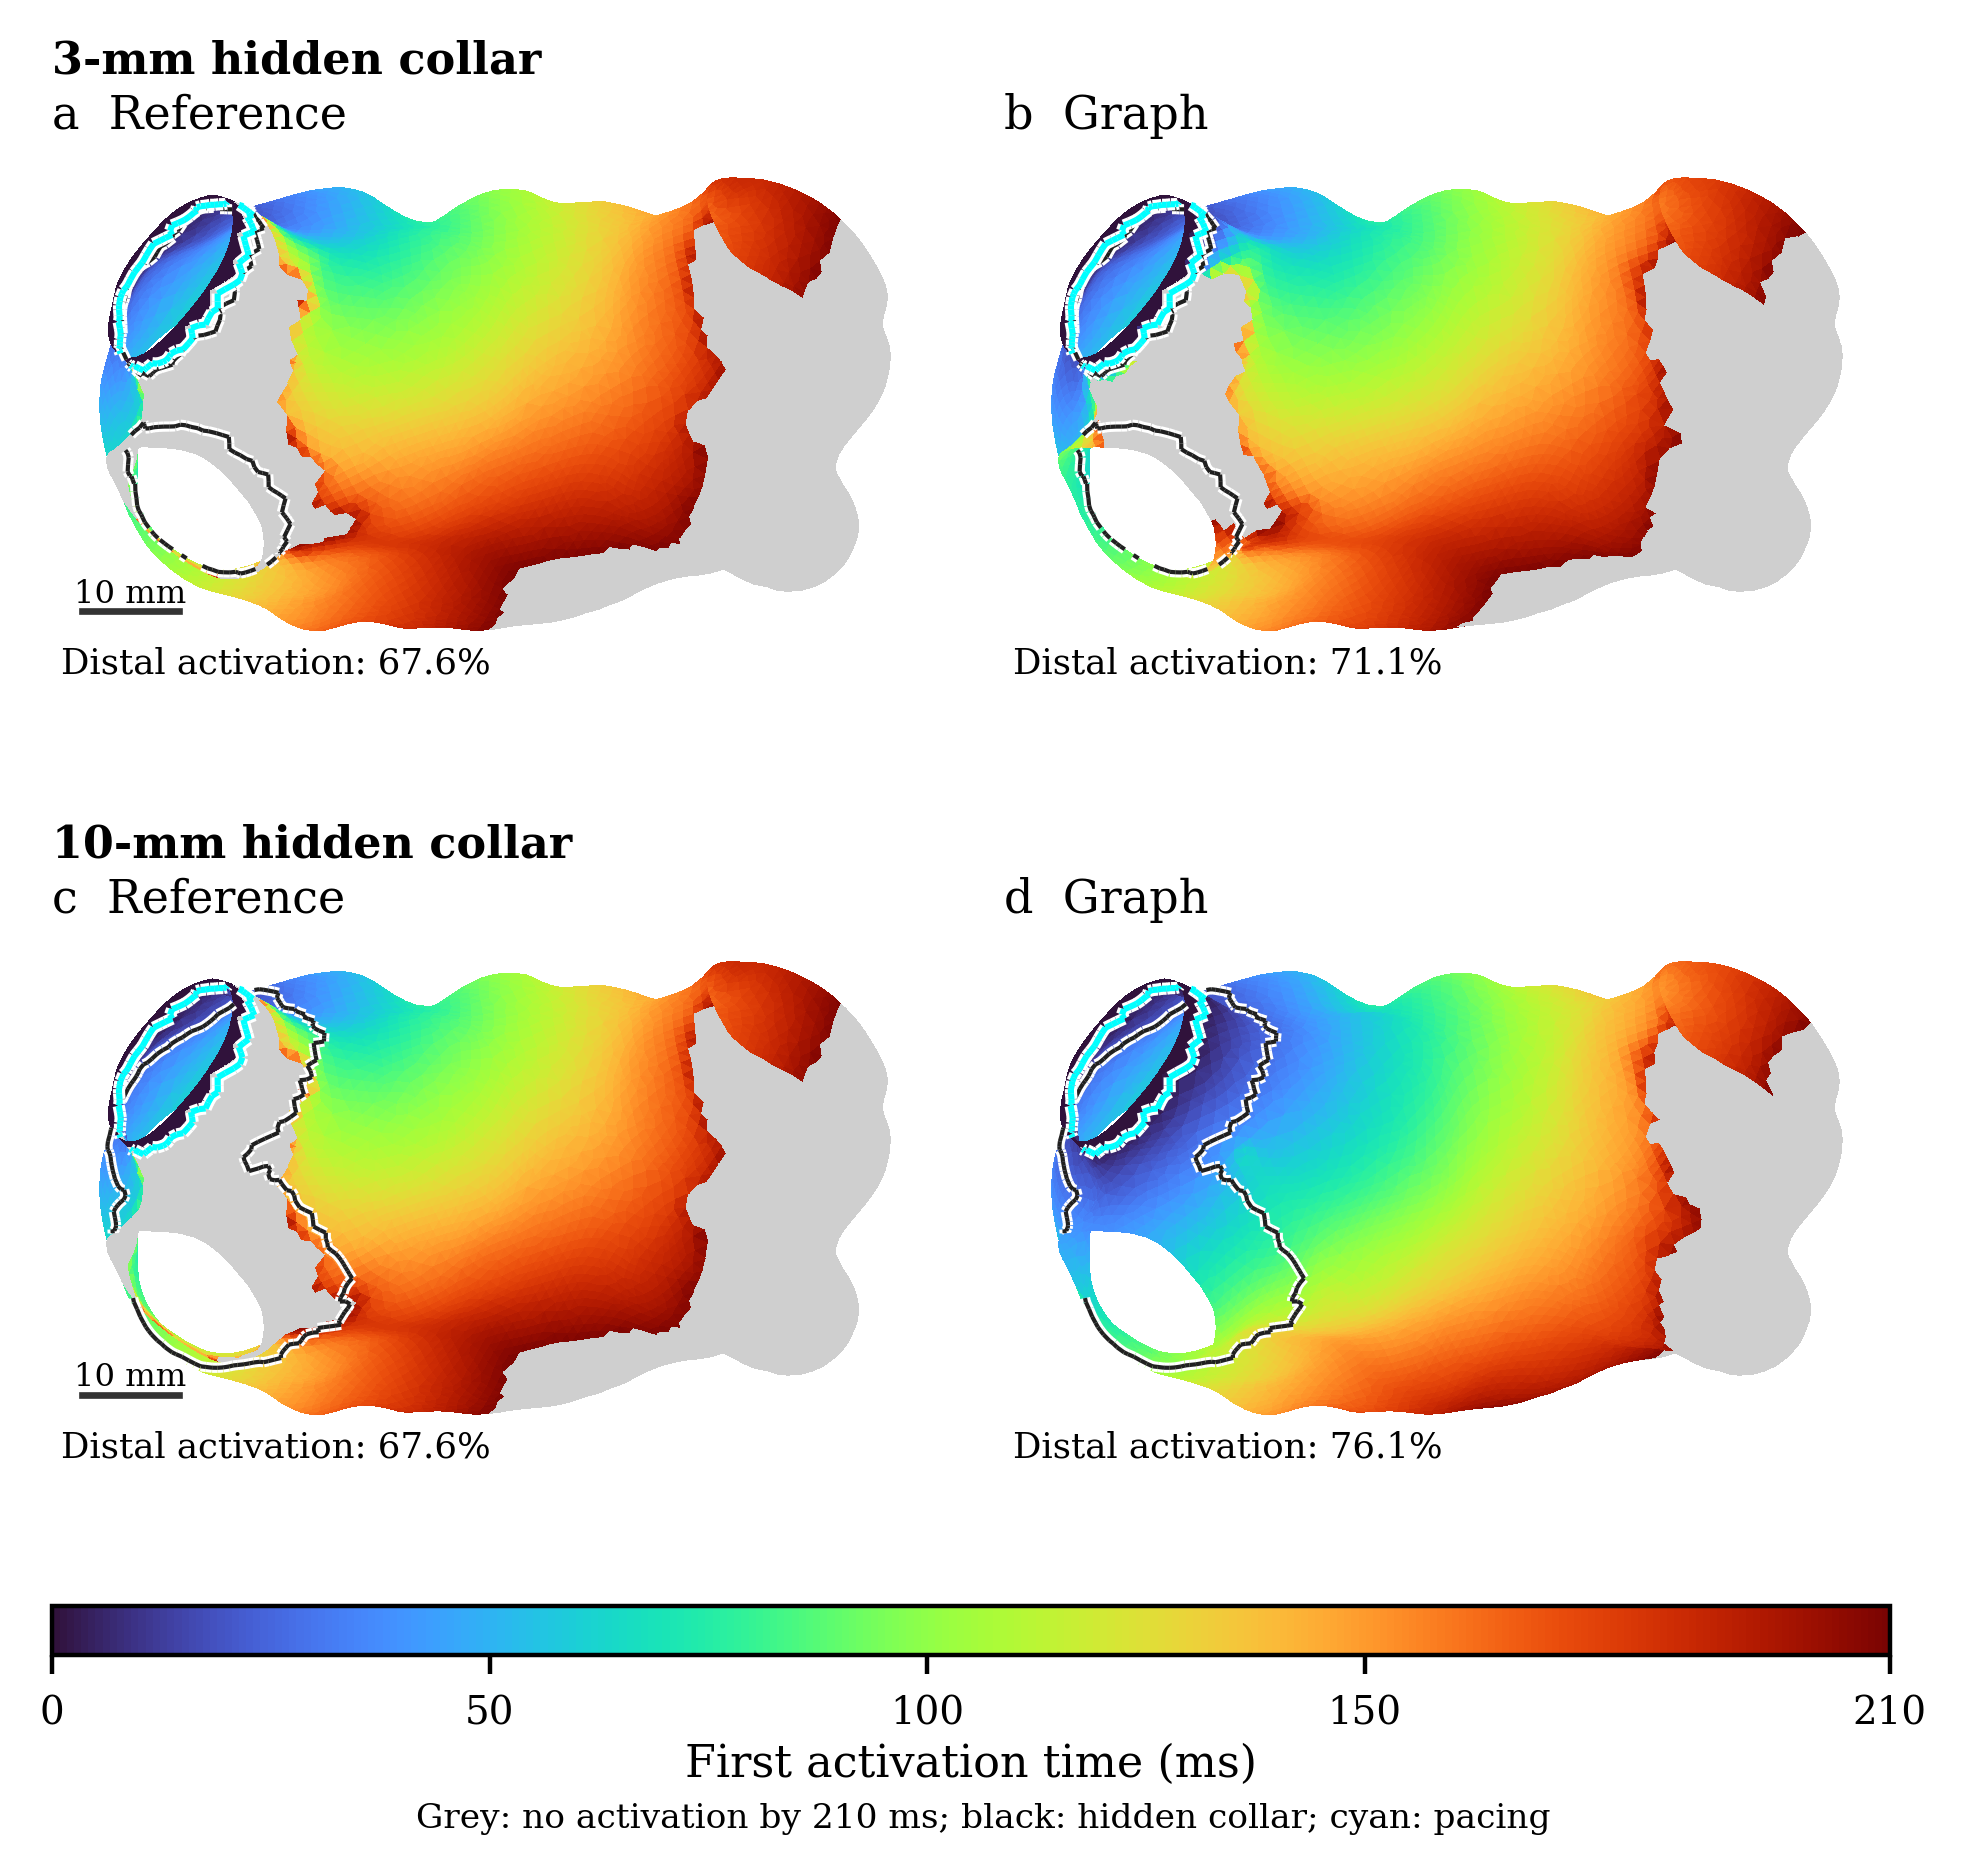

In [13]:
table("tab:patient-surface-ep")
figure("patient_surface_ep")

## Conduction-scale characterisation

Study,\(\Delta x\) (mm),\(\Delta t\) (ms),direction,CV (m/s),APD\(_{90}\) (ms)
space,1.00,0.01,longitudinal,0.5764,164.674
,,,transverse,0.2039,163.894
,0.50,0.01,longitudinal,0.5980,164.813
,,,transverse,0.2257,164.558
,0.25,0.01,longitudinal,0.6042,164.833
,,,transverse,0.2374,164.792
,0.125,0.01,longitudinal,0.6058,164.836
,,,transverse,0.2412,164.829
time,0.50,0.04,longitudinal,0.5927,164.799
,,,transverse,0.2236,164.534


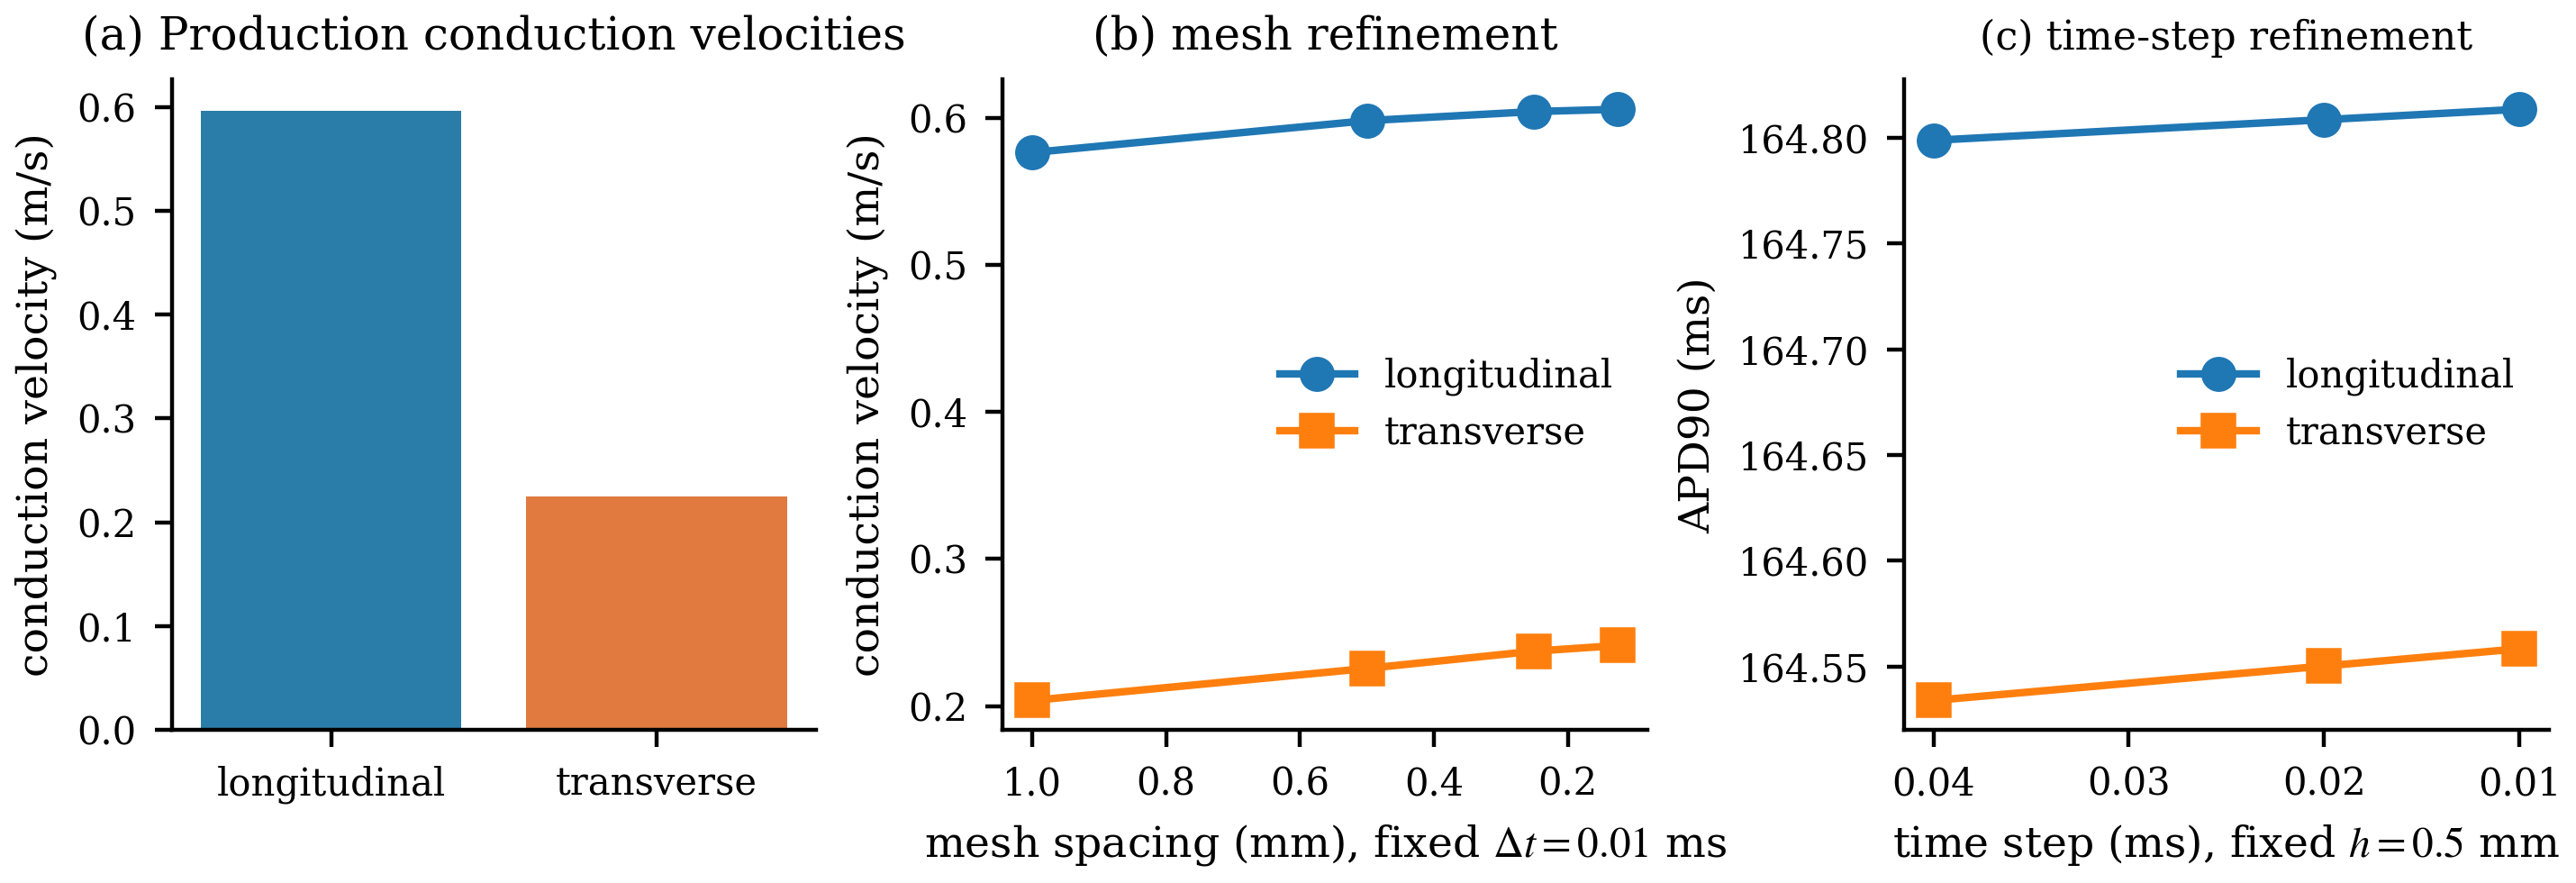

In [14]:
table("tab:calibration")
figure("fig3_conduction_calibration")

## Additional reconstruction results

Metric,screened,passive,graph,graph\(-\)passive
masked score RMSE,1.066011,1.075325,1.069885,\(-0.005440\)
masked scaled-score MSE,0.295368,0.300862,0.298225,\(-0.002637\)
masked ten-bin ECE,0.469621,0.474436,0.471640,\(-0.002797\)
masked Dice,0.162738,0.197597,0.242554,\(+0.044957\)
normalised-capacity absolute error,0.119071,0.111696,0.110254,\(-0.001443\)
gap-count absolute error,0.750000,0.750000,0.750000,0
largest-gap-width absolute error (mm),7.119205,6.848841,6.424312,\(-0.424529\)


Endpoint,Screened,Passive,Graph,Difference
Score RMSE (primary),0.239082,0.238461,0.238335,\(-0.000125\)
Score MAE,0.216965,0.216180,0.215996,\(-0.000184\)
Binned score-calibration error,0.167779,0.166802,0.166514,\(-0.000288\)
Dice at 0.1 mV,0.584855,0.584935,0.582351,\(-0.002584\)
Absolute normalised-capacity error,0.353266,0.353012,0.353087,\(+0.000075\)
Absolute log capacity ratio,1.436549,1.438078,1.438203,\(+0.000126\)
Longest viable-arc error (mm),27.0820,27.0819,27.0829,\(+0.0010\)


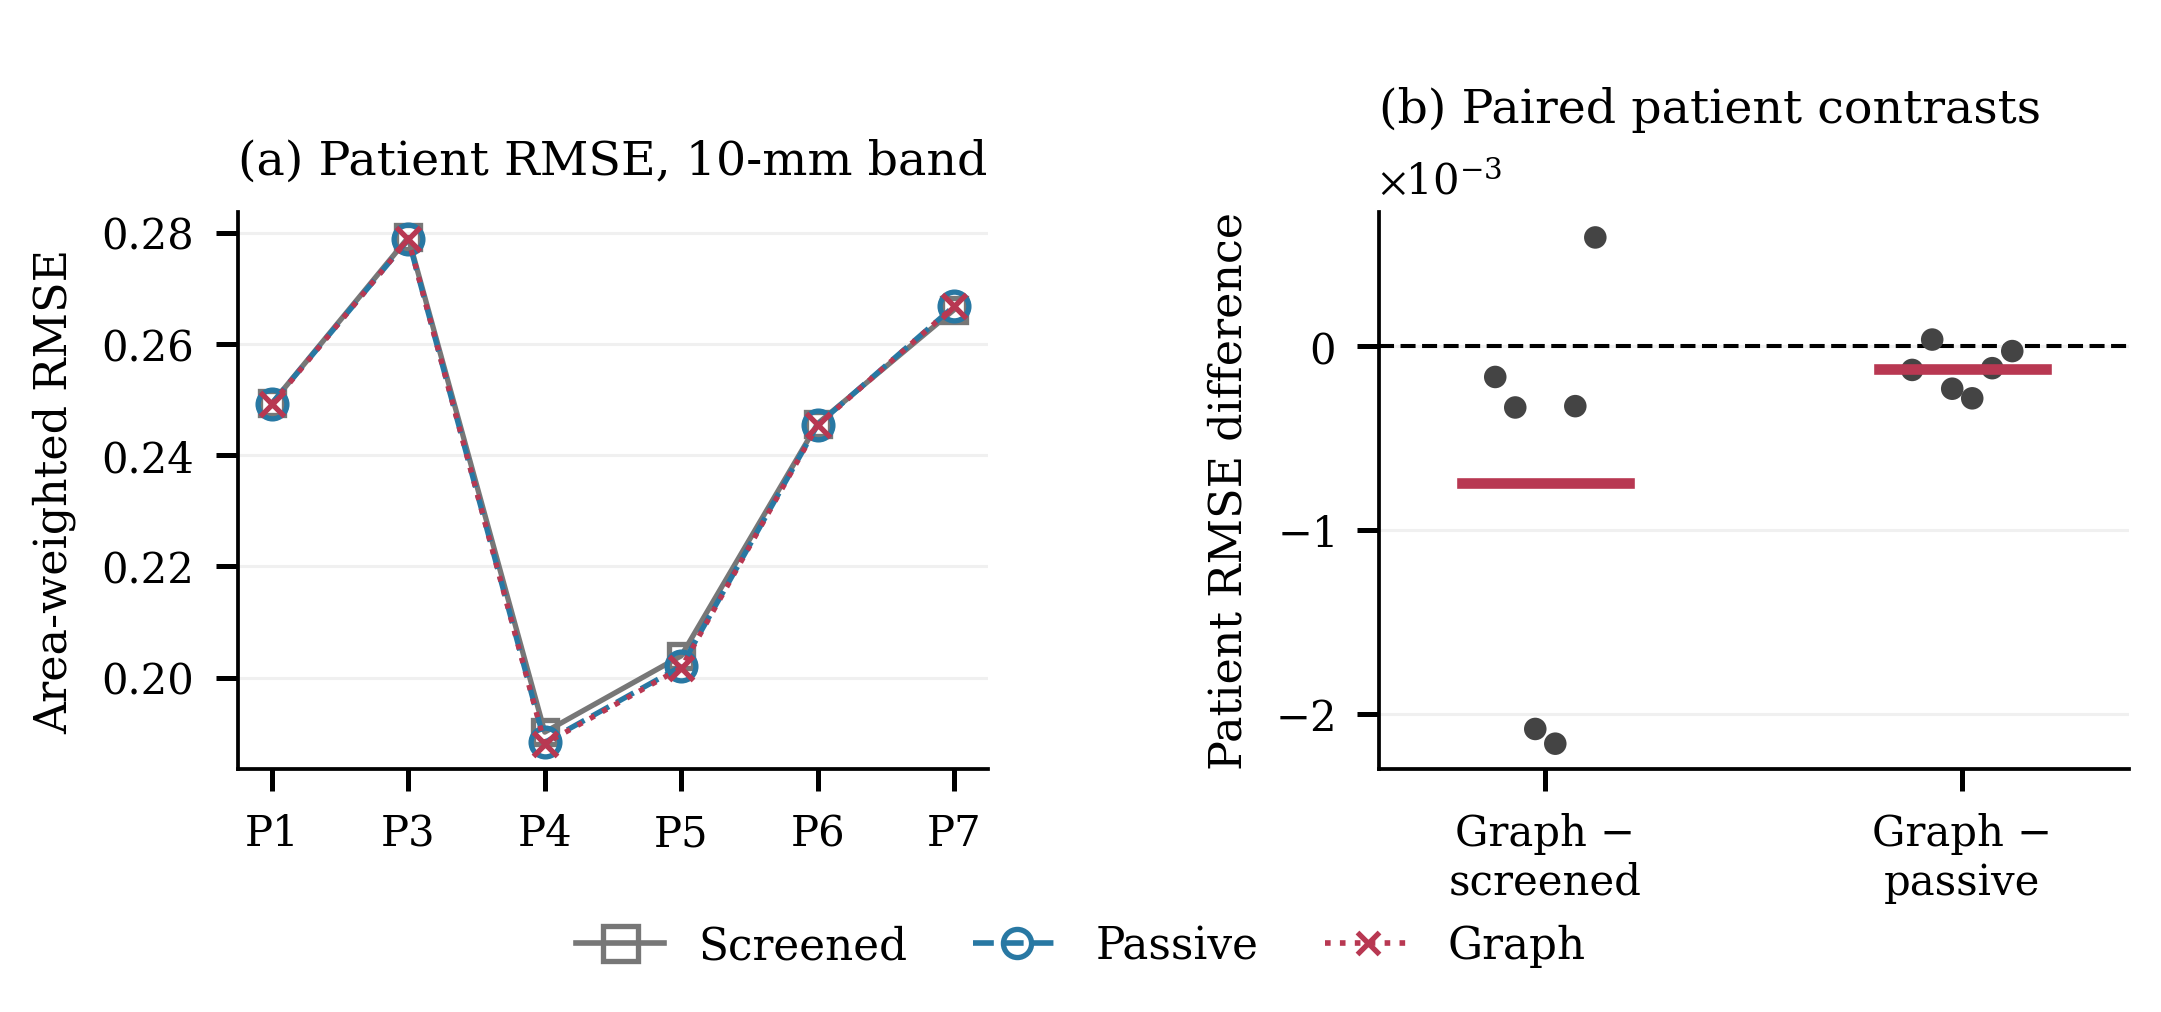

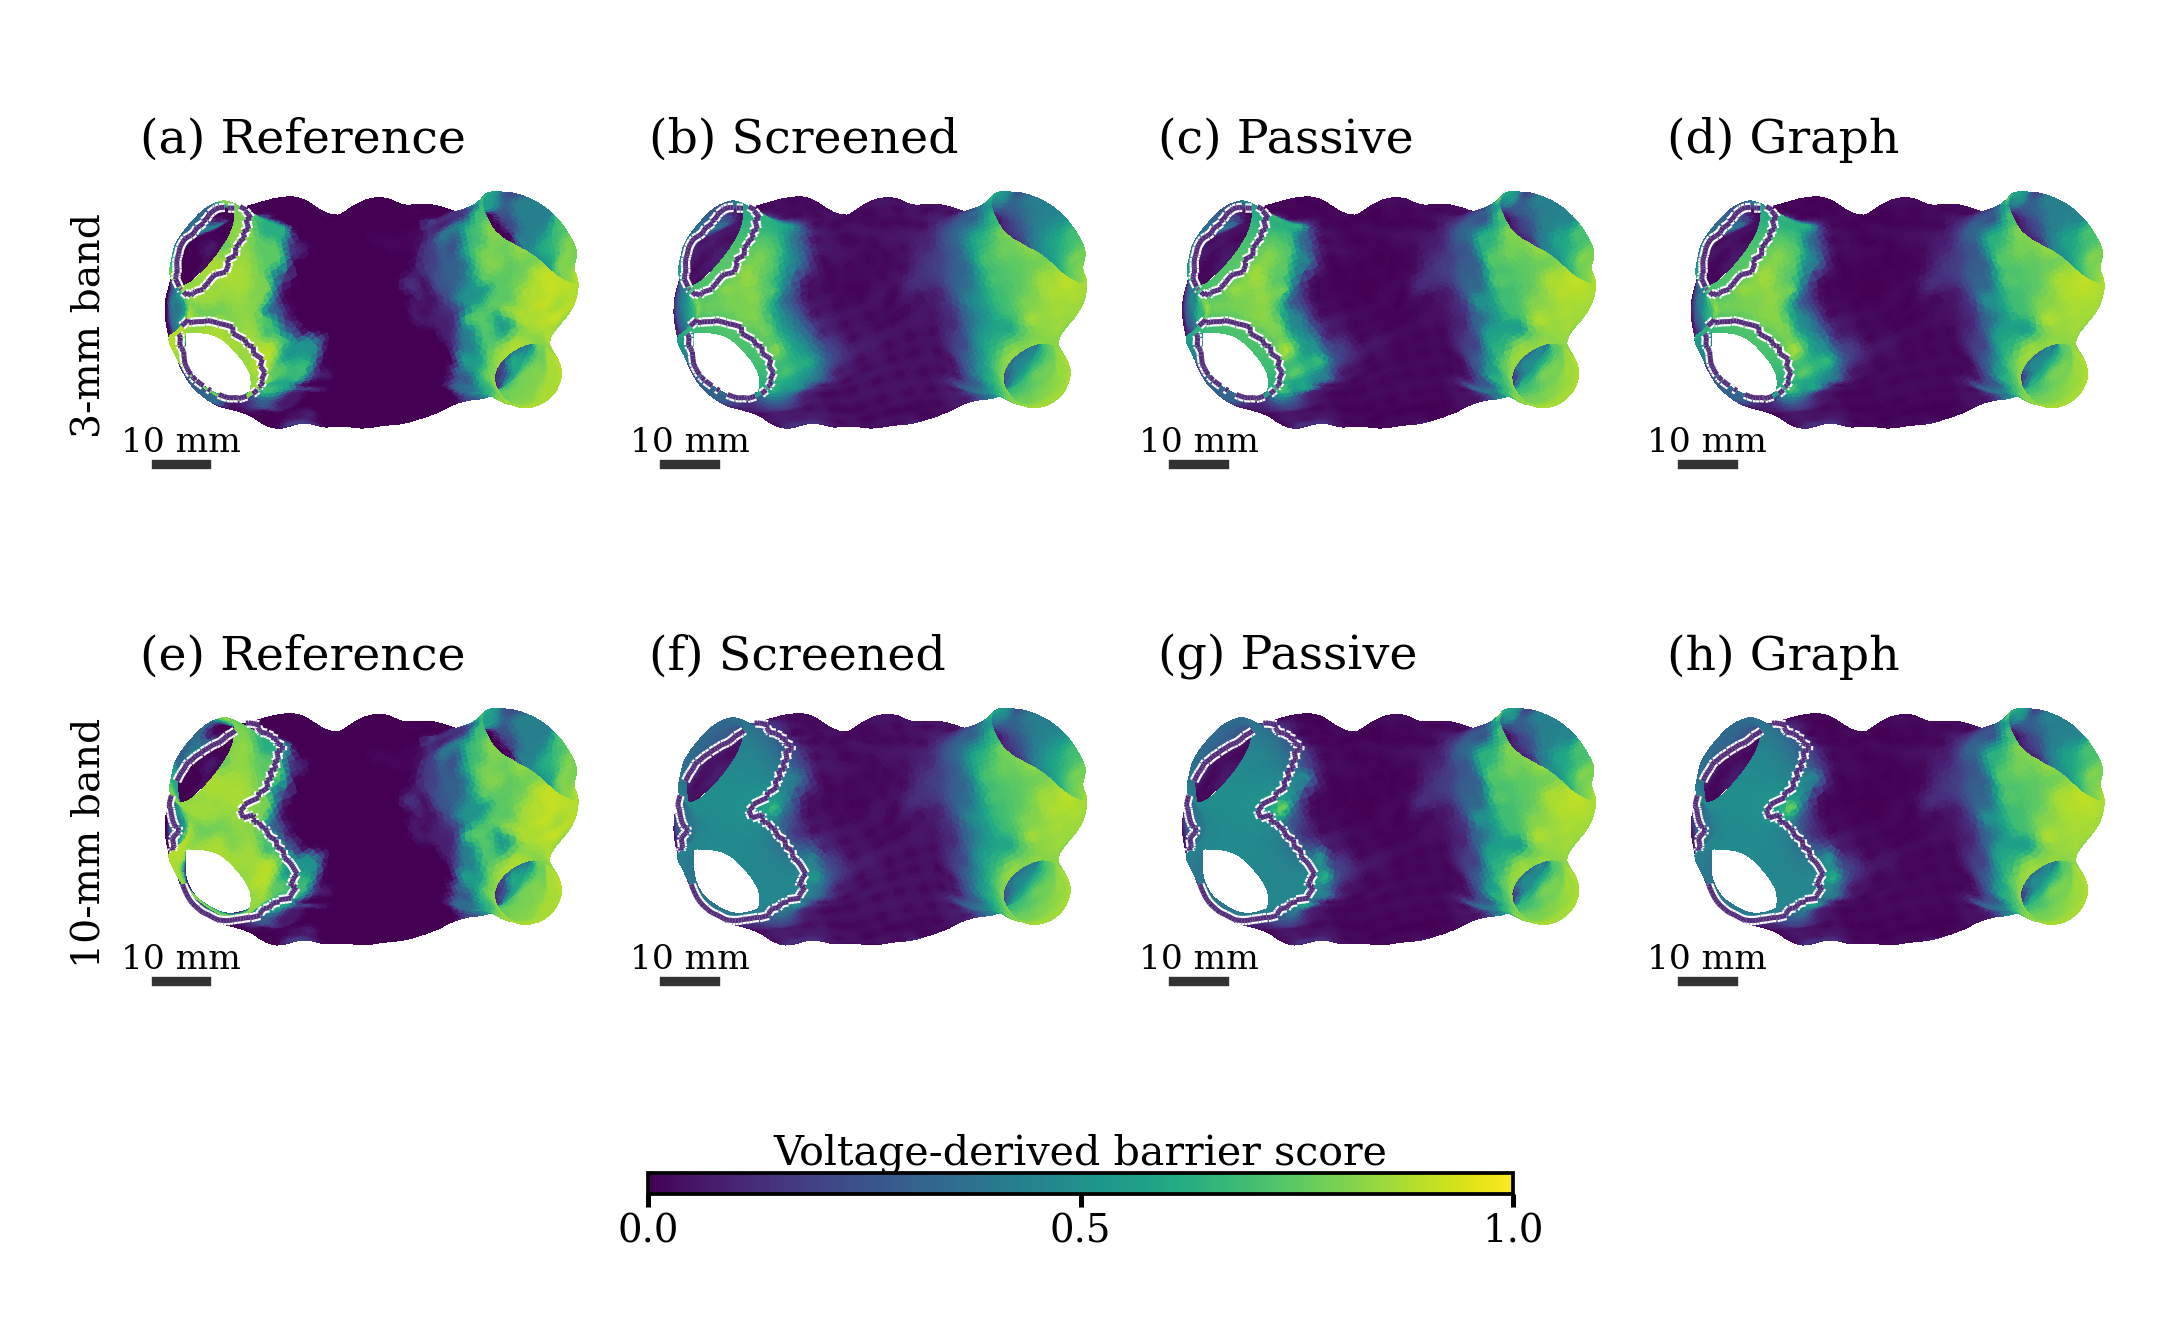

In [15]:
table("tab:sparse")
table("tab:patient-reconstruction-full")
figure("fig_patient_secondary")
figure("fig_patient_surface_comparisons")

## Simulations

In [16]:
for name in ("patient_reconstruction_rotation", "patient_voltage_propagation",
             "rings_closed_contour", "rings_matched_conductance"):
    display(Video(str(REPO / "docs/videos" / (name + ".mp4")), embed=True,
                  html_attributes="controls loop muted playsinline", width=1100))

## Reproducibility

In [17]:
from notebook_report import validate_run, export_results
validation = validate_run(ROOT, WORK)
exports = export_results(ROOT, WORK)
display(validation)

,Check,Count,Passed
0,Fresh computation,12,True
1,Independent numerical checks,11554,True
2,Scientific CSV comparison,66,True
3,Figure outputs,24,True
